# Классификация эмоций по сигналам ЭЭГ и данным айтрекинга с помощью мультимодальных CNN

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
<br>[<b>Шаг 1. Загрузка данных и получение общей информации</b>](#1)
<br>[1.1. Загрузка библиотек](#1.1.)
<br>[1.2. Константы](#1.2.)
<br>[1.3. Загрузка данных](#1.3.)
<br>[<b>Шаг 2. Разведочный анализ данных</b>](#2)
<br>[2.1. Описательные статистики DE-признаков](#2.1.)
<br>[2.2. Временные траектории DE-признаков: визуальный контроль качества сырых сигналов с электродов](#2.2.)
<br>[2.3. Распределение значений DE-признаков по частотным диапазонам](#2.3.)
<br>[2.4. Динамика и форма распределения ЭЭГ-сигналов: сравнение медианы и среднего](#2.4.)
<br>[2.5. Топографические карты головного мозга](#2.5.)
<br>[2.6. Описательные статистики признаков айтрекинга](#2.6.)
<br>[2.7. Корреляции айтрекинга](#2.7.)
<br>[2.8. Тепловая карта изменений признаков по всем 24 триалам сессий](#2.8.)
<br>[2.9. Сравнение ключевых признаков айтрекинга по классам эмоций](#2.9.)
<br>[2.10. Оценка разделимости классов в пространстве признаков айтрекинга (PCA)](#2.10.)
<br>[<b>Шаг 3. Унимодальные модели CNN</b>](#3)
<br>[3.1. Подготовка данных для унимодальных моделей CNN](#3.1.)
<br>[3.1.1. Подготовка сырых данных](#3.1.1.)
<br>[3.1.2. Подготовка данных для моделей №№ 1-4 (топокарты + 4 статистики)](#3.1.2.)
<br>[3.1.3. Подготовка данных для пространственно-временной модели (на сырых сигналах EEGNet)](#3.1.3.)
<br>[3.1.4. Подготовка данных для модели MMD Domain Adaptation](#3.1.4.)
<br>[3.1.5. Подготовка данных для временной модели (TimeDistributed)](#3.1.5.)
<br>[3.1.6. Подготовка данных для временной модели айтрекинга](#3.1.6.)
<br>[3.2. Архитектуры унимодальных моделей](#3.2.)
<br>[3.3. Функции для запуска моделей](#3.3.)
<br>[3.3.1. Функция запуска унимодальных моделей](#3.3.1.)
<br>[3.3.2. Функция запуска для модели MMD Domain Adaptation](#3.3.2.)
<br>[3.4. Обучение унимодальных моделей](#3.4.)
<br>[3.5. Фиксация результатов обучения унимодальных моделей](#3.5.)
<br>[<b>Шаг 4. Мультимодальные модели CNN </b>](#4)
<br>[4.1. Подготовка данных для мультимодальных моделей](#4.1.)
<br>[4.2. Архитектуры мультимодальных моделей](#4.2.)
<br>[4.3. Функция для запуска мультимодальных моделей](#4.3.)
<br>[4.4. Обучение мультимодальных моделей](#4.4.)
<br>[4.5. Фиксация результатов и итоговое сравнение](#4.5.)
<br>[<b>Вывод</b>](#5)
<br>[<b>Источники и литература<b>](#6)
<a id=descr_proj></a>
## Описание проекта

Распознавание эмоций по электроэнцефалограмме (ЭЭГ) представляет собой одну из ключевых и наиболее перспективных задач в области аффективных вычислений. В отличие от традиционных методов, таких как видеонаблюдение за мимикой или субъективные опросники, ЭЭГ предоставляет прямой и объективный доступ к нейронной активности мозга с исключительно высоким временным разрешением, позволяя фиксировать мгновенные и скрытые реакции на эмоциональные стимулы.

Для применения сверточных нейронных сетей (CNN), которые изначально были разработаны для обработки двумерных изображений, непрерывные многоканальные временные ряды ЭЭГ преобразуются в топографические карты мозга (topoplots). Данный алгоритм вычисляет спектральную мощность сигнала в ключевых частотных диапазонах (таких как тета, альфа и бета) для каждого электрода, после чего интерполирует эти значения на двумерную плоскость, создавая полноценное изображение с тремя каналами, аналогичное цветовому формату RGB. Такой подход позволяет нейросети выявлять пространственные паттерны мозговой активности, характерные для разных эмоциональных состояний.

Опора исключительно на центральную нервную систему (ЭЭГ) не всегда позволяет достичь максимальной точности, так как некоторые эмоциональные и вегетативные реакции могут быть скрыты или зашумлены. В рамках данного проекта реализуется мультимодальный фреймворк, в котором сигналы ЭЭГ дополняются данными айтрекинга (eye-tracking). Айтрекинг фиксирует реакции периферической (вегетативной) нервной системы: диаметр зрачка, частоту морганий, параметры саккад и фиксаций взгляда. Эти физиологические маркеры тесно связаны с эмоциональным возбуждением, когнитивной нагрузкой и стрессом (например, расширение зрачка при страхе или учащенное моргание при тревоге). 
Объединение (Late Fusion) пространственно-временных паттернов мозговой активности и вегетативных реакций глаз позволяет создать более устойчивую (robust) систему, способную лучше разделять сложные и амбивалентные эмоциональные состояния.

**Постановка задачи:** разработка и тщательная оптимизация архитектуры свёрточных нейронных сетей (как унимодальных, так и мультимодальных) для надёжной классификации четырёх базовых эмоциональных состояний: радости, грусти, страха и нейтральности. Классификация производится на основе топографических карт ЭЭГ и признаков айтрекинга, сгенерированных из открытого датасета SEED-IV. Особое внимание уделить контролю над переобучением, корректной нормализации разномасштабных признаков и предоставлению полной интерпретации метрик качества.

<a id=descr_data></a>
## Описание данных

Датасет **SEED-IV** (SJTU Emotion EEG Dataset) представляет собой открытый для академического использования набор данных, разработанный лабораторией BCMI ([Brain and Cognitive Machine Intelligence](https://bcmi.sjtu.edu.cn/home/seed/?spm=a2ty_o01.29997173.0.0.3f6355fbBXbLul)) Шанхайского университета Цзяо Тун (Китай) специально для задач распознавания эмоций. Этот набор является эволюцией оригинального датасета SEED и отличается расширенным количеством классов эмоциональных состояний, а также высокой степенью детализации записей. В ходе предварительного исследования для проведения эксперимента были тщательно отобраны 72 видеоклипа, которые с высокой вероятностью вызывают эмоции радости, грусти, страха или нейтральное состояние. В эксперименте приняли участие **15 испытуемых** (7 мужчин и 8 женщин). Для каждого участника было проведено **3 сеанса** в разные дни, каждый из которых содержал **24 испытания (триала)**. В ходе одного испытания участник просматривал видеоклип, в то время как его сигналы ЭЭГ и движения глаз регистрировались с помощью 62-канальной системы `ESI NeuroScan` и очков для айтрекинга `SMI`.

Схема расположения электродов (система 10–20, вид сверху):

```
                                /\
                               /  \
                         FP1   FPZ FP2
                           AF3       AF4
           F7   F5   F3   F1   FZ   F2   F4   F6   F8
       FT7   FC5   FC3   FC1   FCZ   FC2   FC4   FC6   FT8
       (   T7   C5   C3   C1   CZ   C2   C4   C6   T8   )
       TP7   CP5   CP3   CP1   CPZ   CP2   CP4   CP6   TP8
           P7   P5   P3   P1   PZ   P2   P4   P6   P8
             PO7   PO5   PO3   POZ   PO4   PO6   PO8
                    CB1   O1   OZ   O2   CB2
```

*На рисунке вид сверху: нос (`/\`) вверху, уши (`(` `)`) по бокам. Нечётные электроды — левое полушарие (в оригинале голубые), чётные — правое (розовые), средняя линия (FPZ, FZ, FCZ, CZ, CPZ, PZ, POZ, OZ) — чёрные. Оригинальная стендартная схема монтажа прилагается в репозитории исследования: `9. Стандартная схема монтажки электродов для снятия сигналов ЭЭГ.png`*

Каждый сеанс разбивается на неперекрывающиеся сегменты (скользящие временные окна) длительностью **4 секунды** и каждый такой сегмент рассматривается как один отдельный образец данных при обучении модели. Метки классов для трех сессий одних и тех же испытуемых строго зафиксированы. Числовые метки 0, 1, 2 и 3 обозначают соответственно: **нейтральное состояние,** **грусть,** **страх** и **радость.**
* **Сессия 1:** `[1, 2, 3, 0, 2, 0, 0, 1, 0, 1, 2, 1, 1, 1, 2, 3, 2, 2, 3, 3, 0, 3, 0, 3]`
* **Сессия 2:** `[2, 1, 3, 0, 0, 2, 0, 2, 3, 3, 2, 3, 2, 0, 1, 1, 2, 1, 0, 3, 0, 1, 3, 1]`
* **Сессия 3:** `[1, 2, 2, 1, 3, 3, 3, 1, 1, 2, 1, 0, 2, 3, 3, 0, 2, 3, 0, 0, 2, 0, 1, 0]`

**I. Описание данных ЭЭГ**
<br>Запись нейронной активности осуществлялась с помощью 62-канальной ЭЭГ-системы `ESI NeuroScan` с исходной частотой дискретизации 1000 Гц. В рамках предобработки данные даунсэмплируются до **200 Гц** и подвергаются полосовой фильтрации в диапазоне от **1 до 75 Гц** для устранения шумов и физиологических артефактов. Для каждого 4-секундного сегмента вычисляются характеристики спектральной плотности мощности (PSD) и дифференциальной энтропии (DE) в пяти частотных диапазонах:
* **Дельта:** 1–4 Гц
* **Тета:** 4–8 Гц
* **Альфа:** 8–14 Гц
* **Бета:** 14–31 Гц
* **Гамма:** 31–50 Гц

Полагаем критически важным указать на особенность данных: топографические карты ЭЭГ имеют строгую анатомическую привязку к реальной структуре головы человека. В связи с этим к данным ЭЭГ **категорически неприменима агрессивная аугментация** (случайные повороты или масштабирование), поскольку подобные преобразования разрушают естественную лево-правую асимметрию мозга и генерируют неанатомические артефакты.

**Математическое обоснование расчёта признаков:**
Расчет PSD и DE для случайной величины выглядит следующим образом:

PSD (Power Spectral Density / Спектральная плотность мощности):
$$ \text{PSD} = E[x^2] $$

DE (Differential Entropy / Дифференциальная энтропия):
$$ \text{DE} = -\int_{-\infty}^{\infty} P(x)\ln(P(x))dx $$

Авторы предполагали, что сигналы ЭЭГ подчиняются нормальному (гауссовскому) распределению $x \sim N(\mu, \sigma^2)$. Тогда расчет признаков DE можно упростить до:
$$ \text{DE} = \frac{1}{2} \ln(2\pi e \sigma^2) $$
где $\sigma^2$ — дисперсия сигнала в данном частотном диапазоне.

**II. Описание данных айтрекинга**
<br>Для информации о движениях глаз, собранной с помощью очков айтрекинга SMI, мы извлекли различные признаки из детальных параметров, используемых в научной литературе. Данные включают в себя диаметр зрачка, фиксацию, саккаду и моргание. В исходном виде данные хранятся в отдельных файлах для каждого триала (например, `{SubjectName}_{Date}_blink.mat`, `_fixation.mat`, `_pupil.mat`, `_saccade.mat`, `_event.mat`), а затем агрегируются в сглаженные признаки. Итоговый набор признаков айтрекинга состоит из 31 признака в разрезе колиства временных окон. Подробный список признаков движений глаз приведен в таблице ниже:

| Наименование | Параметр | Признак | Описание | Единицы | Типичный диапазон |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Feature 1 | диаметр зрачка | Pupil Diameter X - Mean | Средний диаметр зрачка по оси X | px | ~77-124 |
| Feature 2 | диаметр зрачка | Pupil Diameter Y - Mean | Средний диаметр зрачка по оси Y | px | ~48-80 |
| Feature 3 | диаметр зрачка | Pupil Diameter X - Std | Стандартное отклонение диаметра X | px | ~4.7-11.7 |
| Feature 4 | диаметр зрачка | Pupil Diameter Y - Std | Стандартное отклонение диаметра Y | px | ~4.9-9.0 |
| Feature 5 | диаметр зрачка | Pupil Diameter X - DE (0-0.2 Hz) | Differential Entropy, дельта-диапазон | - | ~24-26 |
| Feature 6 | диаметр зрачка | Pupil Diameter Y - DE (0-0.2 Hz) | Differential Entropy, дельта-диапазон | - | ~25-26 |
| Feature 7 | диаметр зрачка | Pupil Diameter X - DE (0.2-0.4 Hz) | Differential Entropy, тета-диапазон | - | ~14-16 |
| Feature 8 | диаметр зрачка | Pupil Diameter Y - DE (0.2-0.4 Hz) | Differential Entropy, тета-диапазон | - | ~11-16 |
| Feature 9 | диаметр зрачка | Pupil Diameter X - DE (0.4-0.6 Hz) | Differential Entropy, альфа-диапазон | - | ~23-25 |
| Feature 10 | диаметр зрачка | Pupil Diameter Y - DE (0.4-0.6 Hz) | Differential Entropy, альфа-диапазон | - | ~23-25 |
| Feature 11 | диаметр зрачка | Pupil Diameter X - DE (0.6-1 Hz) | Differential Entropy, бета-диапазон | - | ~14-16 |
| Feature 12 | диаметр зрачка | Pupil Diameter Y - DE (0.6-1 Hz) | Differential Entropy, бета-диапазон | - | ~12-15 |
| Feature 13 | дисперсия | Dispersion X - Mean | Средняя дисперсия по оси X | ° | ~8.6-18.5 |
| Feature 14 | дисперсия | Dispersion Y - Mean | Средняя дисперсия по оси Y | ° | ~11-18 |
| Feature 15 | дисперсия | Dispersion X - Std | Стандартное отклонение дисперсии X | ° | ~8.4-19 |
| Feature 16 | дисперсия | Dispersion Y - Std | Стандартное отклонение дисперсии Y | ° | ~9.8-20 |
| Feature 17 | длительность фиксации | Fixation Duration - Mean | Средняя длительность фиксации | ms | ~152-253 |
| Feature 18 | длительность фиксации | Fixation Duration - Std | Стандартное отклонение длительности фиксации | ms | ~82-200 |
| Feature 19 | длительность моргания | Blink Duration - Mean | Средняя длительность моргания | ms | ~76-85 |
| Feature 20 | длительность моргания | Blink Duration - Std | Стандартное отклонение длительности моргания | ms | ~4-65 |
| Feature 21 | саккады | Saccade Amplitude - Mean | Средняя амплитуда саккады | ° | ~17-30 |
| Feature 22 | саккады | Saccade Duration - Mean | Средняя длительность саккады | ms | ~4-186 |
| Feature 23 | статистика событий | Blink Frequency | Частота морганий | Hz | ~0.3-0.6 |
| Feature 24 | статистика событий | Fixation Frequency | Частота фиксаций | Hz | ~2.5-3.2 |
| Feature 25 | статистика событий | Maximum Fixation Duration | Максимальная длительность фиксации | ms | ~666-5224 |
| Feature 26 | статистика событий | Total Fixation Dispersion | Общая дисперсия фиксаций | ° | ~5075-26322 |
| Feature 27 | статистика событий | Maximum Fixation Dispersion | Максимальная дисперсия фиксаций | ° | ~178-2315 |
| Feature 28 | статистика событий | Saccade Frequency | Частота саккад | Hz | ~2.4-3.6 |
| Feature 29 | статистика событий | Average Saccade Duration | Средняя длительность саккады | ms | ~77-86 |
| Feature 30 | статистика событий | Average Saccade Amplitude | Средняя амплитуда саккады | ° | ~4-65 |
| Feature 31 | статистика событий | Average Saccade Latency | Средняя латентность саккады | ms | ~195-336 |

**Некоторые термины и понятия**
* **DE (Дифференциальная энтропия)** — информационно-теоретическая мера хаотичности или неопределённости непрерывного сигнала (ЭЭГ). Высокое значение DE означает, что сигнал сложен, непредсказуем и несёт много информации; низкое значение указывает на то, что сигнал регулярен и предсказуем.
* **Саккада** — быстрое, скачкообразное движение глаз, резко меняющее точку фиксации взгляда. Это основной механизм поисковой активности и переключения зрительного внимания, который в айтрекинге оценивается по амплитуде (угол поворота), длительности и частоте.
<br>**Авторские права** на датасет принадлежат Центру вычислительных систем, подобных мозгу, и машинного интеллекта факультета компьютерных наук и инженерии, Ключевой лаборатории Комиссии по образованию Шанхая в области интеллектуального взаимодействия и когнитивной инженерии, а также Исследовательскому центру наук о мозге и технологий Шанхайского университета Цзяо Тун, Китай.
<br>**Ссылки для цитирования:** Wei-Long Zheng, Wei Liu, Yifei Lu, Bao-Liang Lu, and Andrzej Cichocki, *EmotionMeter: A Multimodal Framework for Recognizing Human Emotions*. IEEE Transactions on Cybernetics, 2018.
<br>**Контактные данные авторов:** если у вас возникнут вопросы по поводу этого датасета, пожалуйста, свяжитесь с [Вэй-Лун Чжэном](mailto:weilonglive@gmail.com) или [Бао-Лян Лу](mailto:bllu@sjtu.edu.cn).

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

<a id=1.1.></a>
### 1.1. Загрузка библиотек

In [1]:
import os    # для работы с операционной системой (пути, файлы, директории)
import glob  # поиск файлов по заданному шаблону / маске имени
import re    # регулярные выражения и работа с текстом
import pandas as pd # обработка и анализ табличных данных 
import numpy as np  # вычисления и многомерные массивы
import matplotlib.pyplot as plt  # базовые графики и диаграммы
import seaborn as sns  # визуализация статистических данных
import scipy.io as io  # для чтения .mat файлов датасета `SEED-IV`
from collections import defaultdict  # класс словаря для автоматического создания значения по умолчанию для новых ключей
from tqdm import tqdm  # отображение прогресс-бара выполнения циклов
from sklearn.decomposition import PCA # метод главных компонент
import warnings
warnings.filterwarnings('ignore')

# MNE и scipy для топокарт головного мозга
import mne  # обработка, анализ, визуализация нейрофизиологических данных (ЭЭГ)
from scipy.interpolate import griddata  # функция для интерполяции данных на нерегулярной сетке для построения топокарт головного мозга
from PIL import Image  # открытие, обработка и сохранение изображений

# Deep Learning & ML
import tensorflow as tf  # глубокое обучение и вычисления
from tensorflow import keras  # высокоуровневый API для построения и обучения нейронных сетей
from tensorflow.keras import layers, regularizers  # компоненты слоёв CNN и методы регуляризации для борьбы с переобучением
from tensorflow.keras.layers import TimeDistributed, GlobalMaxPooling2D  # спецслои CNN для обработки последовательностей данных и агрегации (пулинга) признаков
from tensorflow.keras.utils import to_categorical  # преобразование меток классов в формат one-hot encoding
from tensorflow.keras.models import Sequential  # класс для последовательного (линейного) построения модели нейронной сети
from sklearn.model_selection import train_test_split  # разделения массивов данных на обучающую и тестовую выборки
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay  # оценка качества классификации и визуализация матрицы ошибок
from scipy.stats import skew, kurtosis  # статистические показатели формы распределения (асимметрия и эксцесс)

# настройки визуализации
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Текущая версия TensorFlow: {tf.__version__}")

Текущая версия TensorFlow: 2.21.0


<a id=1.2.></a>
### 1.2. Константы

Библиотека `MNE` строго следует международной системе `10-20`. Каналы `CB1` и `CB2` (мозжечковые) присутствуют в оригинальном датасете `SEED-IV`, но отсутствуют в стандартной монтажке `standard_1020` библиотеки `MNE`. Из-за этого `MNE` не знает, где их рисовать на голове (датчики этих каналов фиксируются на шее - у самого основания черепа), и выдаёт ошибку. В целом для задач распознавания эмоций по ЭЭГ мозжечковые каналы (`CB1`, `CB2`) считаются наименее информативными и часто содержат много артефактов. Поэтому, в таких случаях стандартная практика в научных работах по `SEED-IV` — исключить эти 2 канала, оставив 60 основных кортикальных каналов, которые идеально ложатся на стандартную монтажку.

In [2]:
# наименования классов в соответствии с авторской документацией
class_names = ['Neutral', 'Sad', 'Fear', 'Happy']

# количество классов
num_classes = 4

# Названия частотных диапазонов согласно описанию SEED-IV
band_names = ['Delta (1–4 Гц)', 'Theta (4–8 Гц)', 'Alpha (8–14 Гц)', 'Beta (14–31 Гц)', 'Gamma (31–50 Гц)']

# метки датасета
SEED_IV_LABELS = {
    1: np.array([1, 2, 3, 0, 2, 0, 0, 1, 0, 1, 2, 1, 1, 1, 2, 3, 2, 2, 3, 3, 0, 3, 0, 3]),
    2: np.array([2, 1, 3, 0, 0, 2, 0, 2, 3, 3, 2, 3, 2, 0, 1, 1, 2, 1, 0, 3, 0, 1, 3, 1]),
    3: np.array([1, 2, 2, 1, 3, 3, 3, 1, 1, 2, 1, 0, 2, 3, 3, 0, 2, 3, 0, 0, 2, 0, 1, 0])
}

# 60 каналов электродов головного мозга (исключаем мозжечковые CB1, CB2 - потому что они находятся на шее у основания черепа)
CH_NAMES_FULL = ['Fp1', 'Fpz', 'Fp2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'Fz', 
                 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2',
                 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4',
                 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 
                 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8',  
                 'PO7', 'PO5', 'PO3', 'POz', 'PO4', 'PO6', 'PO8', 'O1', 'Oz', 'O2']

# индексы каналов электродов для удаления (CB1=57, CB2=61)
EXCLUDE_INDICES = [57, 61]

EYE_TRACKING_FEATURES = {
    1: 'pupil_diameter_x_mean',
    2: 'pupil_diameter_y_mean',
    3: 'pupil_diameter_x_std',
    4: 'pupil_diameter_y_std',
    5: 'pupil_diameter_x_de_0_0.2Hz',
    6: 'pupil_diameter_y_de_0_0.2Hz',
    7: 'pupil_diameter_x_de_0.2_0.4Hz',
    8: 'pupil_diameter_y_de_0.2_0.4Hz',
    9: 'pupil_diameter_x_de_0.4_0.6Hz',
    10: 'pupil_diameter_y_de_0.4_0.6Hz',
    11: 'pupil_diameter_x_de_0.6_1Hz',
    12: 'pupil_diameter_y_de_0.6_1Hz',
    13: 'dispersion_x_mean',
    14: 'dispersion_y_mean',
    15: 'dispersion_x_std',
    16: 'dispersion_y_std',
    17: 'fixation_duration_mean',
    18: 'fixation_duration_std',
    19: 'blink_duration_mean',
    20: 'blink_duration_std',
    21: 'saccade_amplitude_mean',
    22: 'saccade_duration_mean',
    23: 'blink_frequency',
    24: 'fixation_frequency',
    25: 'max_fixation_duration',
    26: 'total_fixation_dispersion',
    27: 'max_fixation_dispersion',
    28: 'saccade_frequency',
    29: 'avg_saccade_duration',
    30: 'avg_saccade_amplitude',
    31: 'avg_saccade_latency'
}

<a id=1.3.></a>
### 1.3. Загрузка данных

In [3]:
# функция для загрузки данных
def load_all_raw_data(base_path):
    """Загружает ЭЭГ и айтрекинг в единый словарь"""
    data_dict = defaultdict(dict)
    
    eeg_paths = glob.glob(os.path.join(base_path, 'eeg_feature_smooth/*/*.mat'))
    eye_paths = glob.glob(os.path.join(base_path, 'eye_feature_smooth/*/*.mat'))
    
    print(f"Найдено {len(eeg_paths)} файлов ЭЭГ и {len(eye_paths)} файлов айтрекинга.")
    
    # ЗАГРУЗКА ЭЭГ
    for path in eeg_paths:
        parts = path.split(os.sep)
        session = int(parts[-2])
        subj = int(re.search(r'(\d+)_\d{8}', parts[-1]).group(1))
        
        if subj not in data_dict:
            data_dict[subj] = {'sessions': {1: {}, 2: {}, 3: {}}} # записи данных ЭЭГ проходили в течение трёх сессий

        # Linear dynamic system (LDS) - линейная динамическая система это один из подходов для фильтрации шумов и артефактов, не связанные с особенностями ЭЭГ
        mat_data = io.loadmat(path)
        eeg_trials = {f"de_LDS{i}": mat_data[f"de_LDS{i}"] for i in range(1, 25) if f"de_LDS{i}" in mat_data}  # извлекаем только нужные ключи de_LDS1..24
        data_dict[subj]['sessions'][session]['eeg'] = eeg_trials

    # ЗАГРУЗКА EYETRACKING
    for path in eye_paths:
        parts = path.split(os.sep)
        session = int(parts[-2])
        subj = int(re.search(r'(\d+)_\d{8}', parts[-1]).group(1))
        if subj not in data_dict:
            data_dict[subj] = {'sessions': {1: {}, 2: {}, 3: {}}}
            
        mat_data = io.loadmat(path)
        eye_trials = {}
        
        for i in range(1, 25):
            key = f"eye_{i}"
            if key in mat_data:
                data_array = mat_data[key]
                if data_array.ndim == 2:
                    # УСРЕДНЁННЫЕ данные для Dense-моделей и стандартного EDA
                    eye_trials[key] = np.mean(data_array, axis=1) 
                    # СЫРЫЕ данные для визуализации волн и временной модели CNN
                    eye_trials[f"{key}_raw"] = data_array 
                elif data_array.ndim == 1:
                    eye_trials[key] = data_array
                    eye_trials[f"{key}_raw"] = data_array.reshape(-1, 1)
                    
        data_dict[subj]['sessions'][session]['eye'] = eye_trials

    return data_dict

In [4]:
# загрузка данных

# загрузка данных с kagglehub:
# base_path = kagglehub.dataset_download("phhasian0710/seed-iv")

# загрузка локальных данных:
base_path = r"C:\Users\Pellaero\.cache\kagglehub\datasets\phhasian0710\seed-iv\versions\1"
RAW_DATA = load_all_raw_data(base_path)
print(f"Загружены данные для {len(RAW_DATA)} испытуемых.")

Найдено 45 файлов ЭЭГ и 45 файлов айтрекинга.
Загружены данные для 15 испытуемых.


## Шаг 2. Разведочный анализ данных
Цель данного этапа — понять внутреннюю структуру данных, оценить распределения, выявить аномалии и определить, насколько хорошо признаки (ЭЭГ и айтрекинг) разделяют целевые классы эмоций до начала обучения нейронных сетей.

Анализ разделен на две логические части:
1. **Анализ ЭЭГ (DE-признаки):** оценка временной динамики, пространственного распределения и топологии.
2. **Анализ айтрекинга:** оценка вегетативных реакций, корреляций и информативности 31 признака.

### Разведочный анализ DE-признаков электроэнцефалографии

<a id=2.1.></a>
### 2.1. Описательные статистики DE-признаков ЭЭГ

In [5]:
def summarize_eeg_trial_styled(RAW_DATA, subj=1, sess=1, trial=1):
    """Выводит стилизованную таблицу статистик DE-признаков по частотным диапазонам"""
    target_key = f"de_LDS{trial}"
    eeg_data = RAW_DATA[subj]['sessions'][sess]['eeg'][target_key]
    
    stats_list = []
    for b_idx, band_name in enumerate(band_names):
        band_values = eeg_data[:, :, b_idx].flatten()  # Берем все данные по конкретному диапазону и схлопываем в 1D для статистики
        stats_list.append({
            'Частотный диапазон': band_name,
            'Среднее': np.mean(band_values),
            'Медиана': np.median(band_values),
            'Стд. откл.': np.std(band_values),
            'Минимум': np.min(band_values),
            'Максимум': np.max(band_values)
        })
        
    df_stats = pd.DataFrame(stats_list)
    numeric_cols = ['Среднее', 'Медиана', 'Стд. откл.', 'Минимум', 'Максимум']
    
    print(f"Статистика DE-признаков (Subject {subj}, Session {sess}, Trial {trial})")
    display(df_stats.style.format("{:.4f}", subset=numeric_cols)
            .background_gradient(cmap='Blues', subset=['Среднее', 'Стд. откл.'])
            .set_caption("Значения дифференциальной энтропии (DE) по каналам и диапазонам\n"))
    
summarize_eeg_trial_styled(RAW_DATA, subj=1, sess=1, trial=1)

Статистика DE-признаков (Subject 1, Session 1, Trial 1)


,Частотный диапазон,Среднее,Медиана,Стд. откл.,Минимум,Максимум
0,Delta (1–4 Гц),24.8920,25.0978,1.1571,22.4343,27.7977
1,Theta (4–8 Гц),22.7621,22.9632,0.9198,20.7981,25.0094
2,Alpha (8–14 Гц),21.9047,21.9416,0.7051,20.1946,22.8582
3,Beta (14–31 Гц),20.6318,20.7553,0.6193,19.1004,21.8066
4,Gamma (31–50 Гц),18.4728,18.5050,0.5326,17.3798,20.4382


Анализ описательных статистик дифференциальной энтропии (DE) демонстрирует четкую и физиологически обоснованную закономерность: значения энтропии монотонно снижаются по мере увеличения частоты колебаний. Дельта-диапазон (1–4 Гц) характеризуется наибольшими средними значениями и разбросом, тогда как гамма-диапазон (31–50 Гц) показывает наименьшие показатели, что согласуется с известными свойствами мозговых ритмов, где низкочастотные волны обладают большей амплитудой и энергией. Близость медианы к среднему значению в большинстве диапазонов также указывает на отсутствие критических перекосов в распределении данных, подтверждая корректность предварительной обработки сигналов.

<a id=2.2.></a>
### 2.2. Временные траектории DE-признаков: визуальный контроль качества сырых сигналов с электродов

Прежде чем переходить к статистическому анализу, необходимо провести визуальный контроль качества исходных данных. На этом этапе мы:
- убеждаемся, что сигнал не содержит «мёртвых» каналов и грубых артефактов;
- оцениваем характер изменений дифференциальной энтропии (DE) во времени;
- проверяем согласованность поведения соседних электродов.

Ниже приведены траектории DE-признаков для первых четырёх каналов ЭЭГ в **альфа-диапазоне (8–14 Гц)** — наиболее информативном для задач распознавания эмоций.

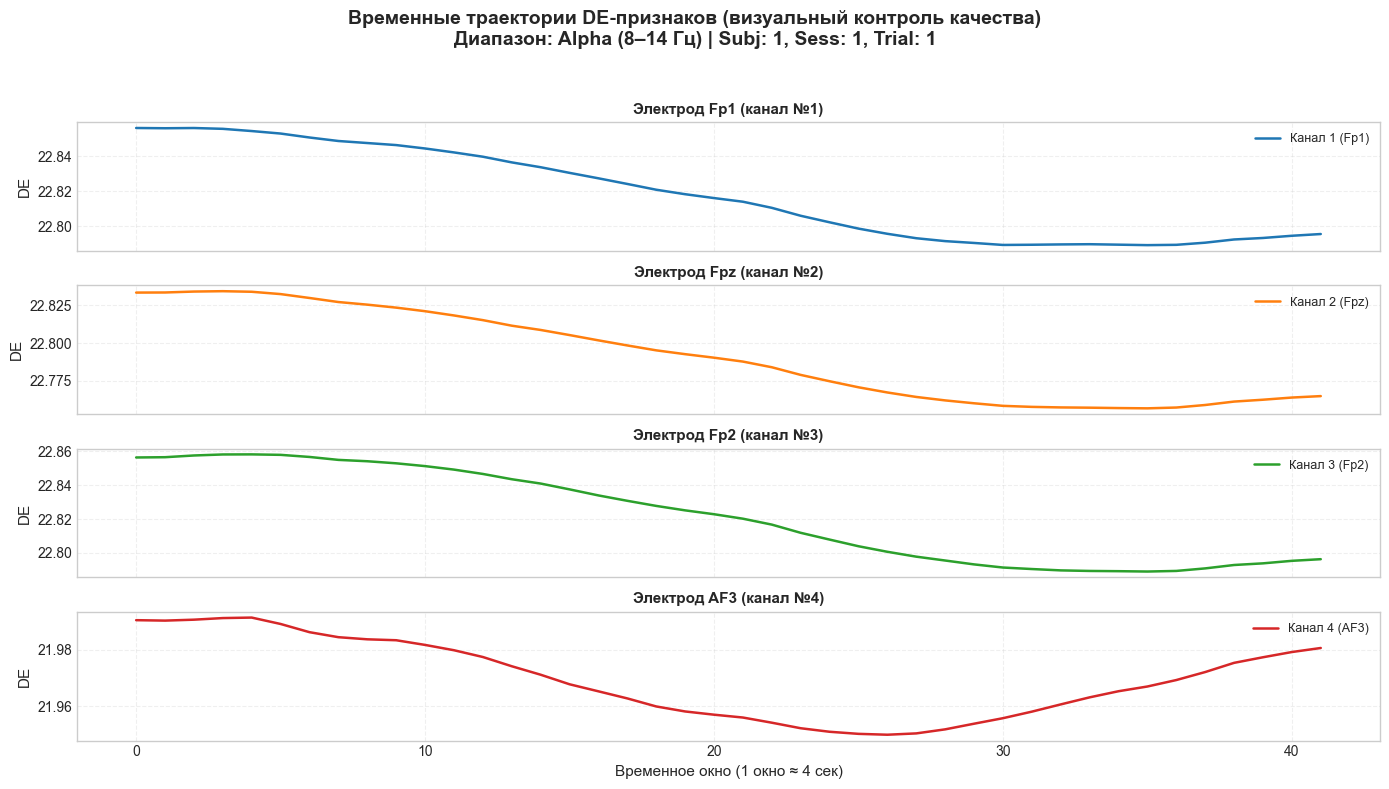

In [6]:
def plot_eeg_trajectories_raw(RAW_DATA, subj=1, sess=1, trial=1, band_idx=2, n_channels_to_show=4):
    """
    Визуальный контроль качества: траектории DE-признаков для первых N каналов.
    band_idx=2 соответствует Alpha-диапазону (8-14 Гц).
    """
    target_key = f"de_LDS{trial}"
    eeg_sample = RAW_DATA[subj]['sessions'][sess]['eeg'][target_key]
    n_channels, n_windows, n_bands = eeg_sample.shape
    
    band_name = band_names[band_idx]
    
    fig, axes = plt.subplots(n_channels_to_show, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(
        f'Временные траектории DE-признаков (визуальный контроль качества)\n'
        f'Диапазон: {band_name} | Subj: {subj}, Sess: {sess}, Trial: {trial}',
        fontsize=14, fontweight='bold', y=0.98)
    
    time_windows = np.arange(n_windows)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i in range(n_channels_to_show):
        ax = axes[i]
        values = eeg_sample[i, :, band_idx]
        ax.plot(time_windows, values, color=colors[i % len(colors)], linewidth=1.8, label=f'Канал {i+1} ({CH_NAMES_FULL[i]})')
        ax.set_ylabel('DE', fontsize=11)
        ax.set_title(f'Электрод {CH_NAMES_FULL[i]} (канал №{i+1})', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='upper right', fontsize=9)
    
    axes[-1].set_xlabel('Временное окно (1 окно ≈ 4 сек)', fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_eeg_trajectories_raw(RAW_DATA, subj=1, sess=1, trial=1)

Визуальный контроль временных траекторий DE-признаков для первых каналов в альфа-диапазоне позволяет убедиться в высоком качестве исходных сигналов. На графиках отсутствуют признаки «мёртвых» каналов или грубых артефактов, а плавность кривых свидетельствует о стабильности регистрации данных во времени. Кроме того, наблюдается согласованность поведения соседних электродов, что является важным индикатором физиологической достоверности записи и подтверждает пригодность данных для дальнейшего пространственно-временного моделирования без необходимости агрессивной дополнительной фильтрации.

<a id=2.3.></a>
### 2.3. Распределение значений DE-признаков по частотным диапазонам

На этом этапе мы агрегируем данные по всем каналам и смотрим, как распределены значения DE внутри каждого из пяти частотных диапазонов. Box-plot позволяет:
- оценить центральную тенденцию и разброс;
- обнаружить выбросы и аномальные значения;
- сравнить уровни энтропии между диапазонами (ожидаемо: низкочастотные диапазоны дают бо́льшие значения DE).

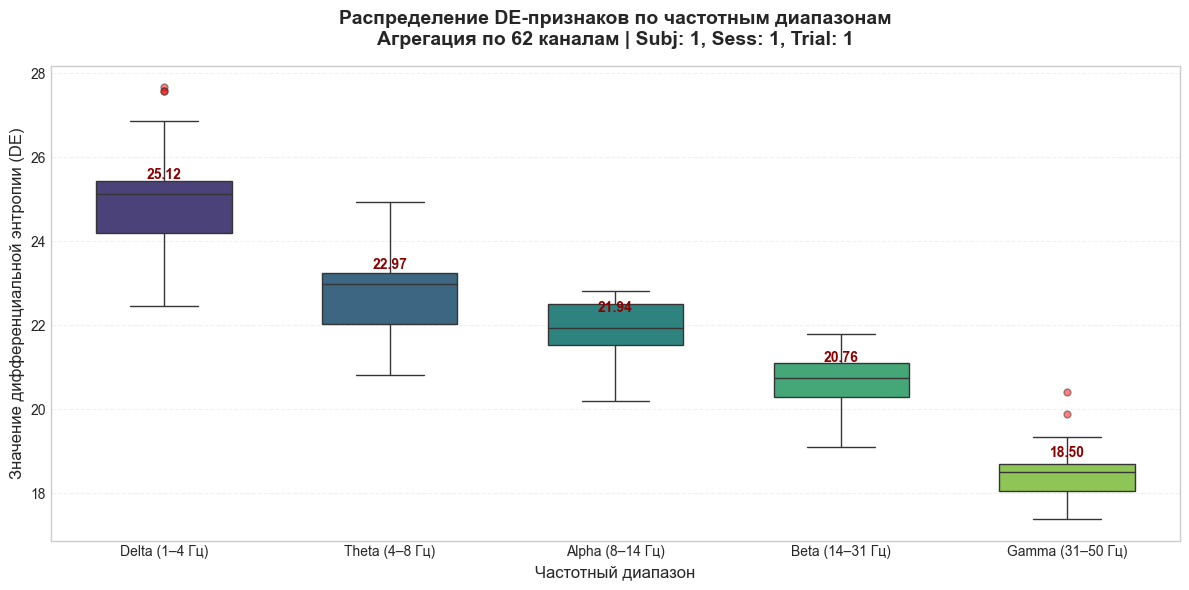

In [7]:
def plot_eeg_band_distributions(RAW_DATA, subj=1, sess=1, trial=1):
    """Boxplot распределения значений DE по 5 частотным диапазонам (все каналы)"""
    target_key = f"de_LDS{trial}"
    eeg_data = RAW_DATA[subj]['sessions'][sess]['eeg'][target_key]
    
    plot_data = []
    for b_idx, band_name in enumerate(band_names):
        # медиана по времени для каждого канала → получаем 62 точки на диапазон
        median_per_channel = np.median(eeg_data[:, :, b_idx], axis=1)
        for val in median_per_channel:
            plot_data.append({'Диапазон': band_name, 'Значение DE': val})
    
    df_plot = pd.DataFrame(plot_data)
    
    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(data=df_plot, x='Диапазон', y='Значение DE', palette='viridis', width=0.6, flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
    
    plt.title(f'Распределение DE-признаков по частотным диапазонам\n' f'Агрегация по {eeg_data.shape[0]} каналам | Subj: {subj}, Sess: {sess}, Trial: {trial}',
        fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Значение дифференциальной энтропии (DE)', fontsize=12)
    plt.xlabel('Частотный диапазон', fontsize=12)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # добавляем подписи с медианными значениями над каждым боксом
    medians = df_plot.groupby('Диапазон')['Значение DE'].median()
    for i, band_name in enumerate(band_names):
        ax.text(i, medians[band_name] + 0.3, f'{medians[band_name]:.2f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkred')
    
    plt.tight_layout()
    plt.show()

plot_eeg_band_distributions(RAW_DATA, subj=1, sess=1, trial=1)

Построение диаграмм box-plot для агрегированных по всем каналам значений DE наглядно иллюстрирует центральную тенденцию и разброс данных внутри каждого из пяти частотных диапазонов. График подтверждает ранее выявленную закономерность о более высоких значениях энтропии в низкочастотных диапазонах, а также позволяет визуально оценить наличие выбросов. Отсутствие экстремальных аномалий и компактность межквартильных размахов говорят о высокой степени однородности извлечённых признаков, что создаёт достаточно благоприятные условия для стабильного обучения нейронной сети.

<a id=2.4.></a>
### 2.4. Динамика и форма распределения ЭЭГ-сигналов: сравнение медианы и среднего

Здесь мы проводим двойной анализ для каждого частотного диапазона:
1. **Слева** — временная динамика: как меняется агрегированный по каналам сигнал от окна к окну. Сравниваются **медиана** (устойчивая к выбросам) и **среднее** (чувствительное к артефактам). Расхождение между ними — индикатор наличия аномальных значений.
2. **Справа** — ядерная оценка плотности распределения (KDE). Показывает форму распределения всех значений DE в данном диапазоне. Вертикальные линии отмечают положение медианы и среднего: чем сильнее они расходятся, тем более асимметрично распределение.

Такой анализ помогает понять, насколько данные «чистые» и какую статистику (медиану или среднее) безопаснее использовать в дальнейшем.

Анализируем Subject: 1, Session: 1, Trial: 1
Форма массива данных: (62, 42, 5)
Подтверждённая структура: 62 каналов, 42 окон, 5 диапазонов.


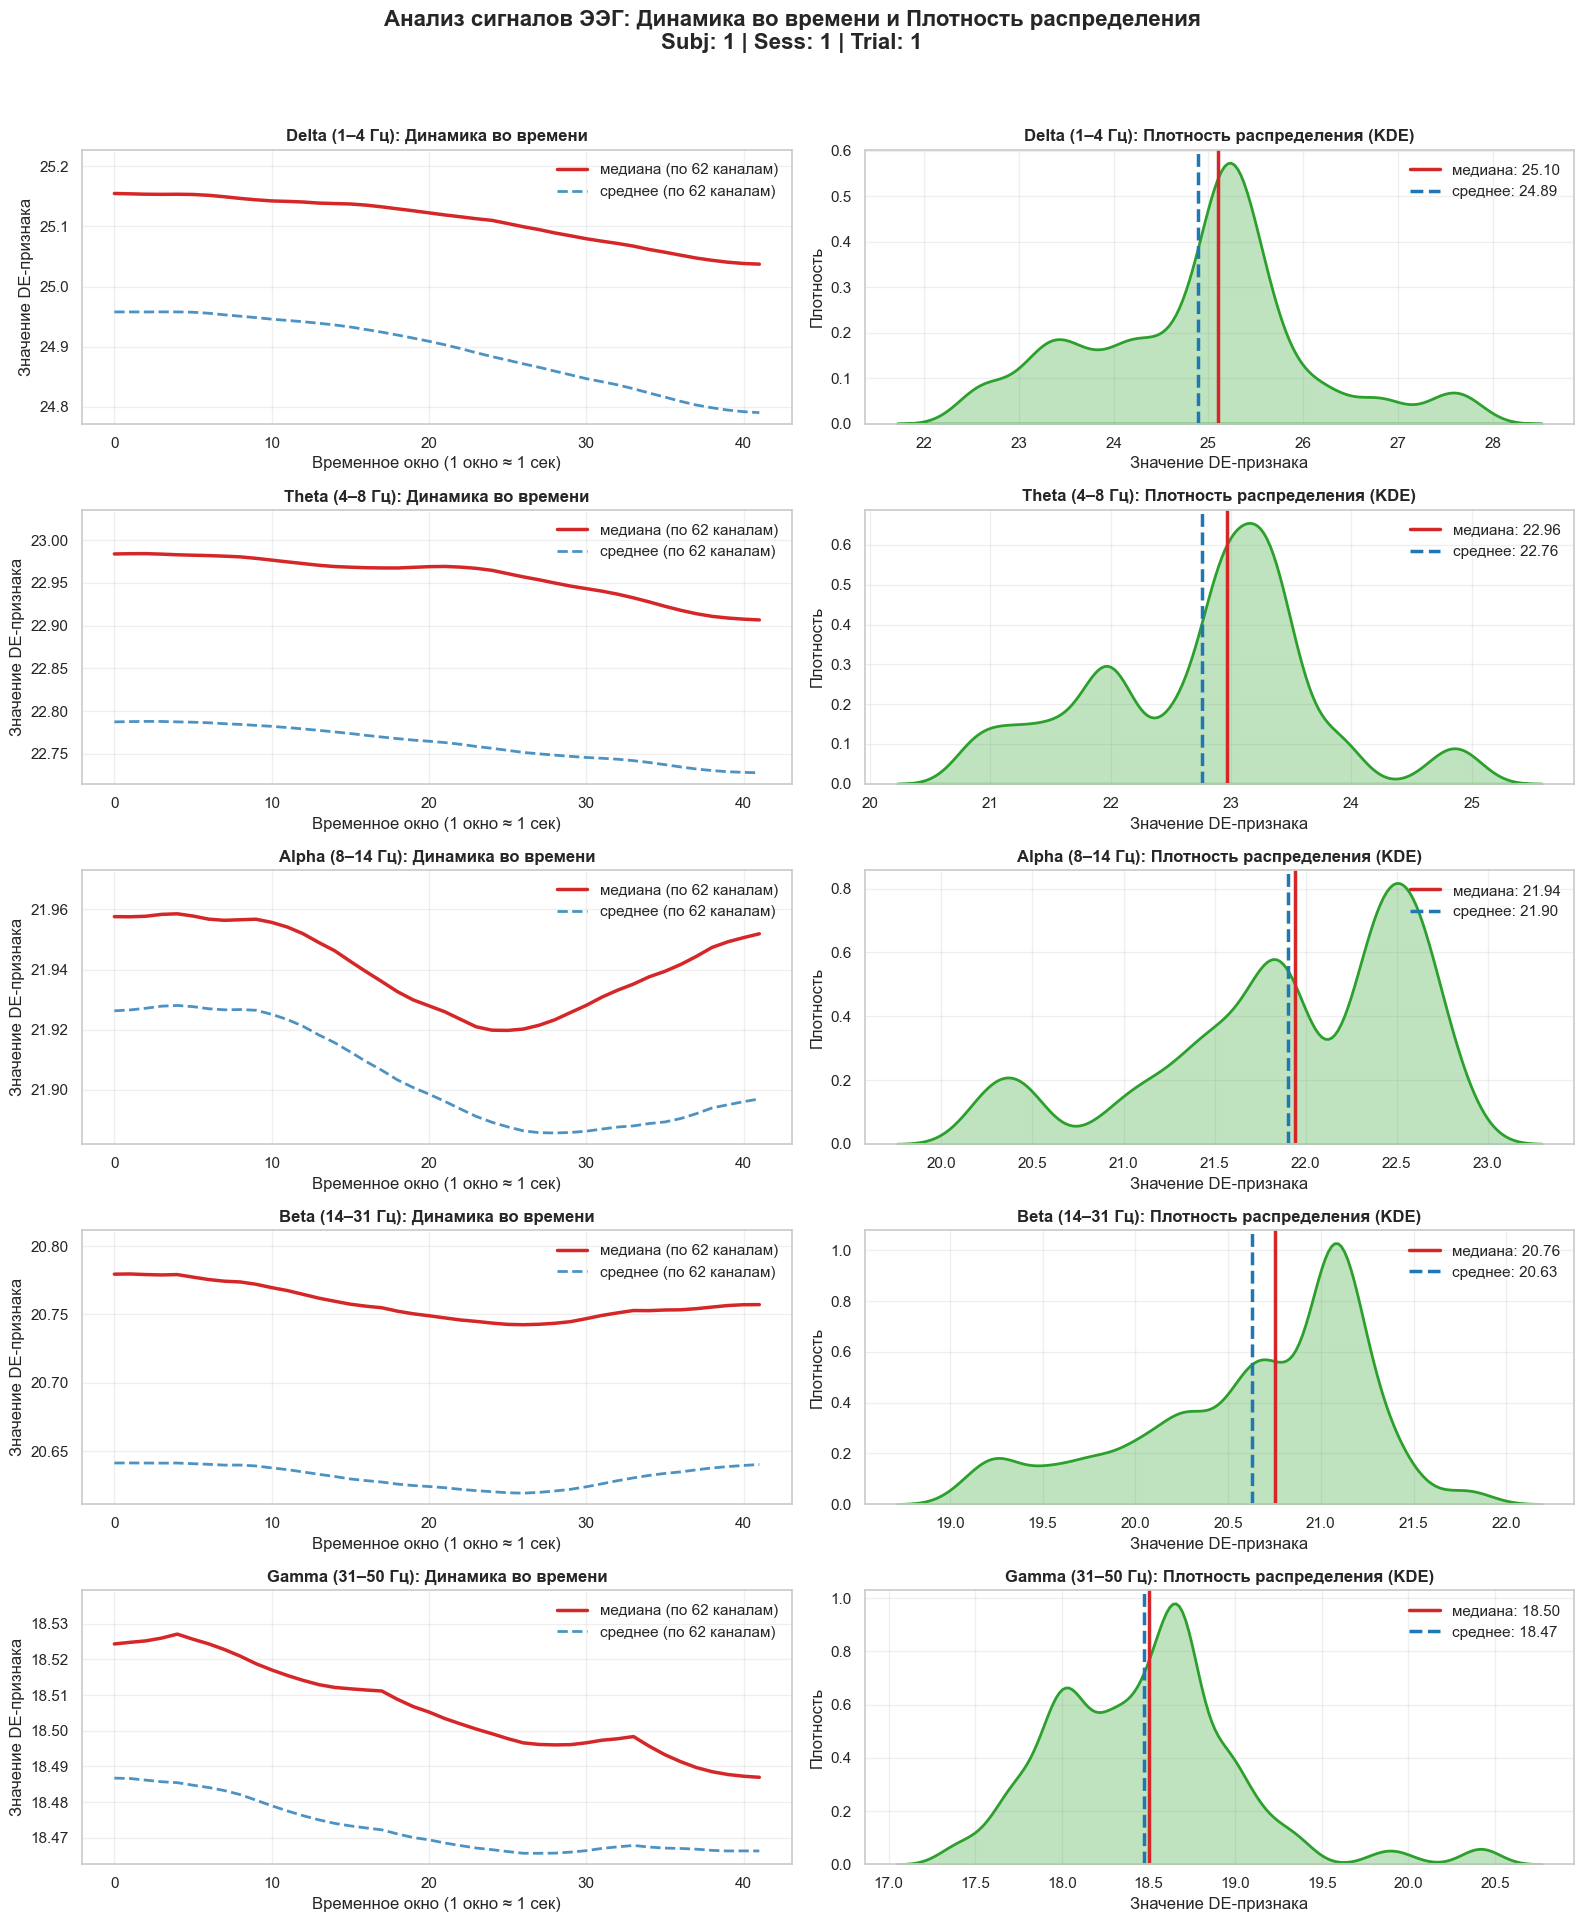

In [8]:
def visualize_eeg_trajectories(RAW_DATA, subj=1, sess=1, trial=1):
    """Визуальный контроль качества данных: траектории признаков DE для анализа"""
    target_key = f"de_LDS{trial}"
    
    # получаем массив данных ЭЭГ из загруженной структуры (логика из Фрагмента 1)
    eeg_sample = RAW_DATA[subj]['sessions'][sess]['eeg'][target_key]
    print(f"Анализируем Subject: {subj}, Session: {sess}, Trial: {trial}")
    print(f"Форма массива данных: {eeg_sample.shape}")

    # распаковка гарантированной 3D-структуры: (каналы, окна, диапазоны)
    n_channels, n_windows, n_bands = eeg_sample.shape
    print(f"Подтверждённая структура: {n_channels} каналов, {n_windows} окон, {n_bands} диапазонов.")

    # настройка стиля для читаемости
    sns.set_theme(style="whitegrid")

    # cоздаём фигуру: n_bands строк и 2 столбца (Время + Распределение)
    fig, axes = plt.subplots(n_bands, 2, figsize=(16, 20))
    fig.suptitle(f'Анализ сигналов ЭЭГ: Динамика во времени и Плотность распределения\n'
                 f'Subj: {subj} | Sess: {sess} | Trial: {trial}', 
                 fontsize=16, fontweight='bold', y=0.98)

    time_windows = np.arange(n_windows) # массив временных окон

    for b in range(n_bands):
        
        band_data = eeg_sample[:, :, b]                  # извлекаем данные для текущего частотного диапазона: форма (n_channels, n_windows)
        median_over_time = np.median(band_data, axis=0)  # вычисляем медиану и среднее по каналам (ось 0) для каждого временного окна
        mean_over_time = np.mean(band_data, axis=0)
        
        # левый столбец: динамика во времени
        ax_time = axes[b, 0]
        ax_time.plot(time_windows, median_over_time, label=f'медиана (по {n_channels} каналам)', color='#d62728', linewidth=2.5)
        ax_time.plot(time_windows, mean_over_time, label=f'среднее (по {n_channels} каналам)', color='#1f77b4', linestyle='--', linewidth=2, alpha=0.8)
        ax_time.set_title(f'{band_names[b]}: Динамика во времени', fontsize=12, fontweight='bold')
        ax_time.set_xlabel('Временное окно (1 окно ≈ 1 сек)')
        ax_time.set_ylabel('Значение DE-признака')
        y_min = min(median_over_time.min(), mean_over_time.min())
        y_max = max(median_over_time.max(), mean_over_time.max())
        y_range = y_max - y_min
        ax_time.set_ylim(y_min - y_range * 0.05, y_max + y_range * 0.20)
        ax_time.legend(loc='upper right')
        ax_time.grid(True, alpha=0.3)
        
        # правый столбец: распределение значений (KDE)
        ax_kde = axes[b, 1]
        flat_band_data = band_data.flatten()  # сплющиваем данные в 1D массив для построения общего распределения
        sns.kdeplot(flat_band_data, ax=ax_kde, color='#2ca02c', fill=True, alpha=0.3, linewidth=2)  # строим KDE-графики (ядерную оценку плотности)
        med_val = np.median(flat_band_data) # добавляем вертикальные линии для оценки разрыва между средним и медианой
        mean_val = np.mean(flat_band_data)
        ax_kde.axvline(med_val, color='#d62728', linestyle='-', linewidth=2.5, label=f'медиана: {med_val:.2f}')
        ax_kde.axvline(mean_val, color='#1f77b4', linestyle='--', linewidth=2.5, label=f'среднее: {mean_val:.2f}')
        ax_kde.set_title(f'{band_names[b]}: Плотность распределения (KDE)', fontsize=12, fontweight='bold')
        ax_kde.set_xlabel('Значение DE-признака')
        ax_kde.set_ylabel('Плотность')
        ax_kde.legend(loc='upper right')
        ax_kde.grid(True, alpha=0.3)

    plt.subplots_adjust(hspace=0.35) # увеличиваем вертикальный отступ между графиками
    plt.tight_layout(rect=[0, 0.02, 1, 0.96]) # подгонка макета, чтобы заголовки не наезжали друг на друга
    plt.show()

visualize_eeg_trajectories(RAW_DATA, subj=1, sess=1, trial=1)

Двойной анализ, включающий оценку временной динамики и ядерную оценку плотности распределения (KDE), дает глубокое понимание «чистоты» сигналов. Сравнение медианы и среднего значения во времени показывает их высокую степень сходимости, что свидетельствует об устойчивости данных к случайным всплескам и артефактам. Графики плотности распределения для каждого частотного диапазона демонстрируют форму, близкую к нормальному (гауссовскому) распределению, что полностью оправдывает использование упрощенной математической формулы расчета дифференциальной энтропии, заложенной в основу данного датасета.

<a id=2.5.></a>
### 2.5. Топографические карты головного мозга
Для использования в CNN мы интерполируем значения с электродов на 2D-плоскость. Проверим, как выглядят паттерны для разных эмоций (на примере Альфа-ритма).

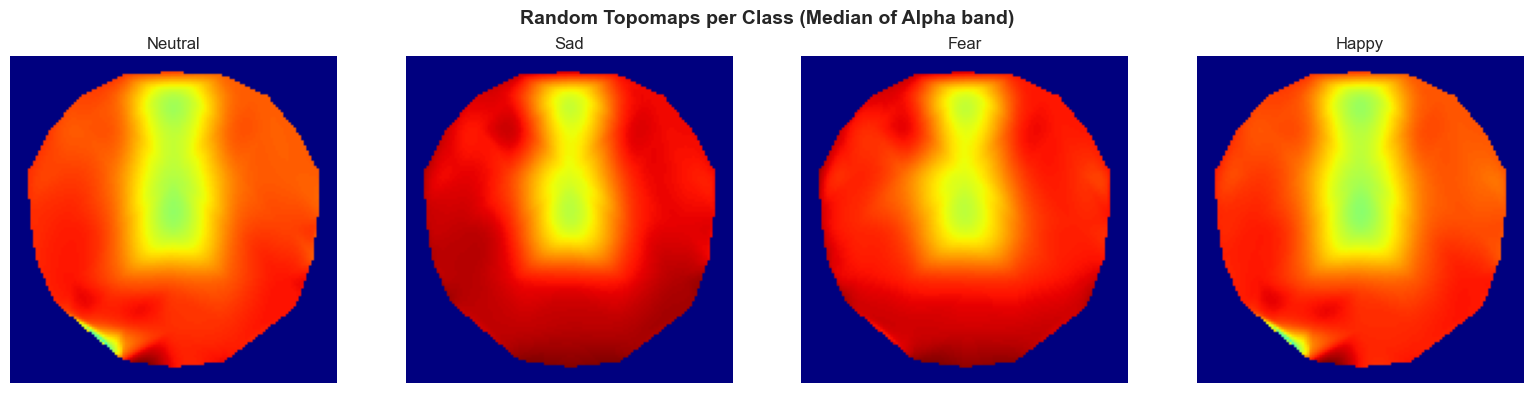

In [9]:
# визуализация примера топокарты на актуальных данных
def get_mne_2d_coords():
    """Получает 2D координаты 60 каналов из MNE"""
    info = mne.create_info(ch_names=CH_NAMES_FULL, sfreq=200, ch_types='eeg')
    info.set_montage('standard_1020', on_missing='ignore')
    ch_pos = info.get_montage().get_positions()['ch_pos']
    
    coords = []
    for ch in CH_NAMES_FULL:
        if ch in ch_pos and ch_pos[ch] is not None:
            coords.append([ch_pos[ch][0]*100, ch_pos[ch][1]*100]) # в см
    return np.array(coords)

COORDS_2D = get_mne_2d_coords()

def generate_topomap_fast(values_1d, coords, img_size=128):
    """Быстрая генерация одной топокарты через scipy"""
    # создаём сетку для интерполяции
    xi = np.linspace(coords[:, 0].min()-1, coords[:, 0].max()+1, img_size)
    yi = np.linspace(coords[:, 1].min()-1, coords[:, 1].max()+1, img_size)
    xi, yi = np.meshgrid(xi, yi)
    
    # интерполяция
    zi = griddata(coords, values_1d, (xi, yi), method='cubic', fill_value=0)
    
    # применяем круговую маску (голова)
    center_x, center_y = np.mean(coords[:, 0]), np.mean(coords[:, 1])
    radius = np.max(np.sqrt((coords[:, 0] - center_x)**2 + (coords[:, 1] - center_y)**2)) + 1
    mask = (xi - center_x)**2 + (yi - center_y)**2 <= radius**2
    zi[~mask] = 0 # фон
    
    # нормализация в 0-255 для изображения
    zi_min, zi_max = np.min(zi[mask]), np.max(zi[mask])
    if zi_max > zi_min:
        zi_norm = (zi - zi_min) / (zi_max - zi_min)
    else:
        zi_norm = np.zeros_like(zi)
        
    return (zi_norm * 255).astype(np.uint8)

def visualize_random_topomaps(RAW_DATA):
    """Рандомная топокарта по 4 классам"""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle('Random Topomaps per Class (Median of Alpha band)', fontsize=14, fontweight='bold')
    
    for i, ax in enumerate(axes):
        # ищем первый попавшийся трейл для класса i
        found = False
        for s in [1, 2, 3]:
            for subj in list(RAW_DATA.keys())[:5]: # смотрим первых 5 испытуемых
                labels = SEED_IV_LABELS[s]
                if i in labels:
                    t_idx = np.where(labels == i)[0][0] + 1
                    eeg = RAW_DATA[subj]['sessions'][s]['eeg'][f"de_LDS{t_idx}"]
                    vals = np.median(eeg[:, :, 2], axis=1)  # берём медиану по времени и усредняем по Альфа-диапазону (индекс 2)
                    vals = np.delete(vals, EXCLUDE_INDICES) # исключаем точки электродов CB1, CB2
                    
                    img = generate_topomap_fast(vals, COORDS_2D, img_size=128)
                    ax.imshow(img, cmap='jet')
                    ax.set_title(class_names[i])
                    ax.axis('off')
                    found = True
                    break
            if found: break
            
    plt.tight_layout()
    plt.show()

visualize_random_topomaps(RAW_DATA)

Визуализация топографических карт для альфа-ритма демонстрирует, как дискретные значения с 60 электродов интерполируются в непрерывные двумерные изображения, сохраняя строгую анатомическую привязку к структуре головы. Различные эмоциональные классы начинают проявлять уникальные пространственные паттерны активности, например, различия в асимметрии между левым и правым полушариями. Это подтверждает обоснованность преобразования временных рядов ЭЭГ в формат изображений для последующей обработки сверточными нейронными сетями, так как архитектура CNN сможет выявлять именно эти локализованные зоны активации.

### Разведочный анализ айтрекинга
Датасет содержит 31 признак движений глаз. Для улучшения читабельности графиков мы вводим систему сокращённых названий, сгруппированных по физиологическому смыслу.

In [10]:
# словарь сокращённых названий признаков айтрекинга 
EYE_SHORT_NAMES = [
    'Pupil_X_Mean', 'Pupil_Y_Mean', 'Pupil_X_Std', 'Pupil_Y_Std',
    'Pupil_X_DE_D', 'Pupil_Y_DE_D', 'Pupil_X_DE_T', 'Pupil_Y_DE_T', 
    'Pupil_X_DE_A', 'Pupil_Y_DE_A', 'Pupil_X_DE_B', 'Pupil_Y_DE_B',
    'Disp_X_Mean', 'Disp_Y_Mean', 'Disp_X_Std', 'Disp_Y_Std',
    'Fix_Dur_Mean', 'Fix_Dur_Std', 'Blink_Dur_Mean', 'Blink_Dur_Std',
    'Sacc_Amp_Mean', 'Sacc_Dur_Mean', 'Blink_Freq', 'Fix_Freq',
    'Max_Fix_Dur', 'Tot_Fix_Disp', 'Max_Fix_Disp', 'Sacc_Freq',
    'Avg_Sacc_Dur', 'Avg_Sacc_Amp', 'Avg_Sacc_Lat'
]

# укрупнённые группы признаков для цветового кодирования
EYE_GROUPS = ['Зрачок']*12 + ['Дисперсия']*4 + ['Фиксация']*2 + ['Моргание']*2 + ['Саккада']*2 + ['Статистика']*9

<a id=2.6.></a>
### 2.6. Описательные статистики признаков айтрекинга

На этом этапе мы агрегируем 31 признак айтрекинга по всем 24 триалам сессии и формируем сводную таблицу описательных статистик. 

Важное замечание для дальнейшего моделирования: как видно из таблицы, признаки имеют **кратный разброс масштабов** (например, частота морганий ~0.4 Гц против общей дисперсии фиксаций ~13000°). Это подтверждает критическую необходимость применения нормализации (Z-score или Min-Max) перед подачей этих данных в нейронную сеть, иначе признаки с большими абсолютными значениями полностью "заглушат" сигналы с малыми значениями.

In [11]:
def summarize_eye_tracking_styled(RAW_DATA, subj=1, sess=1):
    """Формирует и выводит стилизованную таблицу описательных статистик для 31 признака айтрекинга"""
    eye_data = RAW_DATA[subj]['sessions'][sess]['eye']
    
    # cобираем усреднённые данные по всем 24 триалам
    features_list = []
    for i in range(1, 25):
        key = f"eye_{i}"
        if key in eye_data:
            features_list.append(eye_data[key])
            
    # преобразуем в массив: форма (24 триала, 31 признак)
    features_array = np.array(features_list) 
    
    # полные названия признаков известны на основе официальной документации SEED-IV
    # мы используем понятные наименования вместо snake_case для читабельности
    EYE_FULL_NAMES = [
        'Средний диаметр зрачка X (px)', 'Средний диаметр зрачка Y (px)',
        'Стд. откл. диаметра зрачка X', 'Стд. откл. диаметра зрачка Y',
        'DE зрачка X (0-0.2 Гц)', 'DE зрачка Y (0-0.2 Гц)',
        'DE зрачка X (0.2-0.4 Гц)', 'DE зрачка Y (0.2-0.4 Гц)',
        'DE зрачка X (0.4-0.6 Гц)', 'DE зрачка Y (0.4-0.6 Гц)',
        'DE зрачка X (0.6-1 Гц)', 'DE зрачка Y (0.6-1 Гц)',
        'Средняя дисперсия X (°)', 'Средняя дисперсия Y (°)',
        'Стд. откл. дисперсии X', 'Стд. откл. дисперсии Y',
        'Средняя длительность фиксации (мс)', 'Стд. откл. длительности фиксации',
        'Средняя длительность моргания (мс)', 'Стд. откл. длительности моргания',
        'Средняя амплитуда саккады (°)', 'Средняя длительность саккады (мс)',
        'Частота морганий (Гц)', 'Частота фиксаций (Гц)',
        'Макс. длительность фиксации (мс)', 'Общая дисперсия фиксаций (°)',
        'Макс. дисперсия фиксаций (°)', 'Частота саккад (Гц)',
        'Средняя длительность саккады (мс)', 'Средняя амплитуда саккады (°)',
        'Средняя латентность саккады (мс)'
    ]

    # расчёт статистик
    stats_list = []
    for i in range(31):
        feat_values = features_array[:, i]
        stats_list.append({
            'Признак': EYE_FULL_NAMES[i],
            'Среднее': np.mean(feat_values),
            'Медиана': np.median(feat_values),
            'Стд. откл.': np.std(feat_values),
            'Минимум': np.min(feat_values),
            'Максимум': np.max(feat_values)
        })
        
    df_stats = pd.DataFrame(stats_list)
    numeric_cols = ['Среднее', 'Медиана', 'Стд. откл.', 'Минимум', 'Максимум']
    
    print(f"Сводная статистика признаков айтрекинга (Subject {subj}, Session {sess})")
    
    # стилизованный вывод
    # из-за разного масштаба признаков градиент для 'Среднее' будет подсвечивать признаки с самыми большими абсолютными значениями
    display(
        df_stats.style.format("{:.2f}", subset=numeric_cols)
                  .background_gradient(cmap='Blues', subset=['Среднее'])
                  .background_gradient(cmap='Purples', subset=['Стд. откл.'])
                  .set_caption("Описательные статистики 31 признака айтрекинга (агрегация по 24 триалам)")
                  .set_properties(subset=['Признак'], **{'text-align': 'left', 'font-weight': 'bold'})
                  .hide(axis="index") # скрываем стандартный числовой индекс pandas
    )
    
    return df_stats

df_eye_stats = summarize_eye_tracking_styled(RAW_DATA, subj=1, sess=1)

Сводная статистика признаков айтрекинга (Subject 1, Session 1)


Признак,Среднее,Медиана,Стд. откл.,Минимум,Максимум
Средний диаметр зрачка X (px),98.16,94.88,13.79,77.20,123.86
Средний диаметр зрачка Y (px),63.89,64.05,7.66,47.98,80.19
Стд. откл. диаметра зрачка X,7.05,6.68,1.62,4.65,11.74
Стд. откл. диаметра зрачка Y,6.48,6.28,1.06,4.85,9.01
DE зрачка X (0-0.2 Гц),25.17,25.09,0.40,24.51,25.88
DE зрачка Y (0-0.2 Гц),25.50,25.43,0.40,24.84,26.21
DE зрачка X (0.2-0.4 Гц),15.05,15.14,0.58,13.97,16.17
DE зрачка Y (0.2-0.4 Гц),13.69,13.60,0.98,10.98,15.53
DE зрачка X (0.4-0.6 Гц),23.93,23.98,0.35,23.13,24.65
DE зрачка Y (0.4-0.6 Гц),24.26,24.31,0.35,23.46,24.98


Сводная таблица описательных статистик для 31 признака айтрекинга выявляет колоссальный разброс масштабов измеряемых величин. Например, частота морганий измеряется долями герца, тогда как общая дисперсия фиксаций достигает десятков тысяч градусов. Такое критическое различие в порядках величин наглядно демонстрирует, что без применения строгой нормализации (например, Z-score или Min-Max) признаки с большими абсолютными значениями будут полностью доминировать при обучении модели, заглушая информативные, но численно малые вегетативные маркеры.

<a id=2.7.></a>
### 2.7. Корреляции айтрекинга

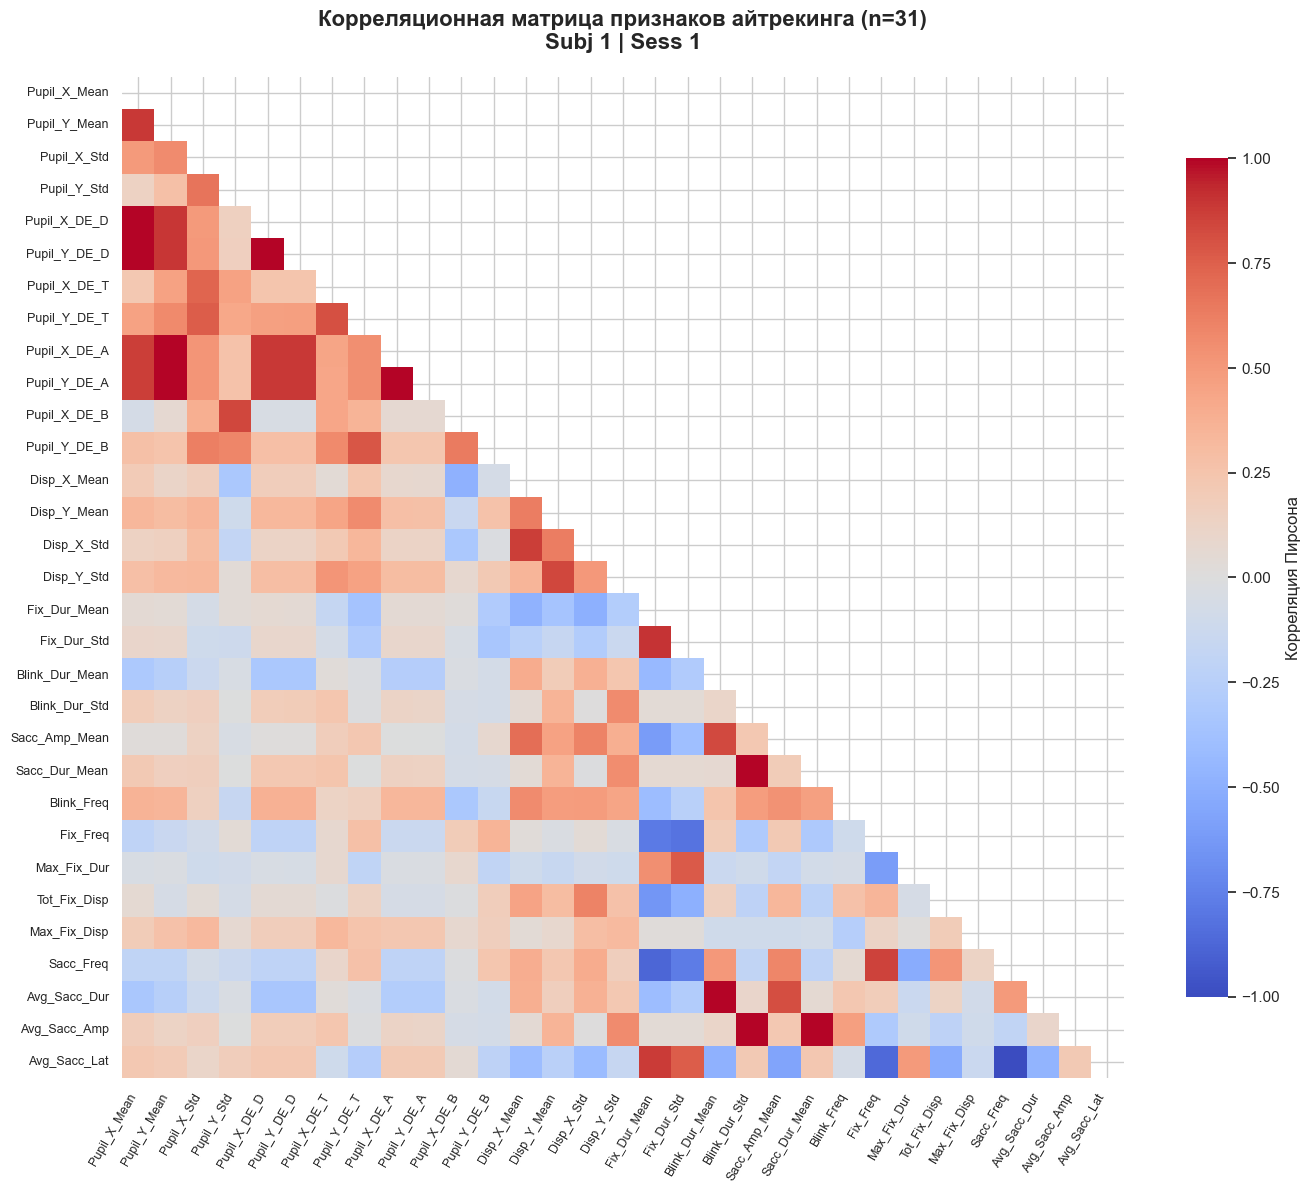

In [12]:
def analyze_eye_correlations(RAW_DATA, subj=1, sess=1):
    eye_data = RAW_DATA[subj]['sessions'][sess]['eye']
    features_list = [eye_data[f"eye_{i}"] for i in range(1, 25) if f"eye_{i}" in eye_data]
    features_array = np.array(features_list)
    
    # корреляционная матрица с короткими названиями
    corr_matrix = np.corrcoef(features_array.T)
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, 
                xticklabels=EYE_SHORT_NAMES, yticklabels=EYE_SHORT_NAMES, cbar_kws={"shrink": .8, "label": "Корреляция Пирсона"})
    plt.xticks(rotation=60, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.title(f'Корреляционная матрица признаков айтрекинга (n=31)\nSubj {subj} | Sess {sess}', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

analyze_eye_correlations(RAW_DATA, subj=1, sess=1)

Корреляционная матрица Пирсона для признаков айтрекинга позволяет выявить скрытые взаимосвязи между различными физиологическими параметрами движений глаз. Наличие сильных положительных или отрицательных корреляций между определенными группами признаков (например, между средним значением и стандартным отклонением диаметра зрачка) указывает на их естественную взаимозависимость. Эта информация крайне важна для дальнейшего моделирования, так как сильно скоррелированные признаки могут дублировать информацию, что требует внимания при интерпретации весов модели, чтобы избежать проблем с мультиколлинеарностью.

<a id=2.8.></a>
### 2.8. Тепловая карта изменений признаков по всем 24 триалам сессии
Примечание: из-за большого количества признаков (31) используется уменьшенный шрифт и сокращенные названия.

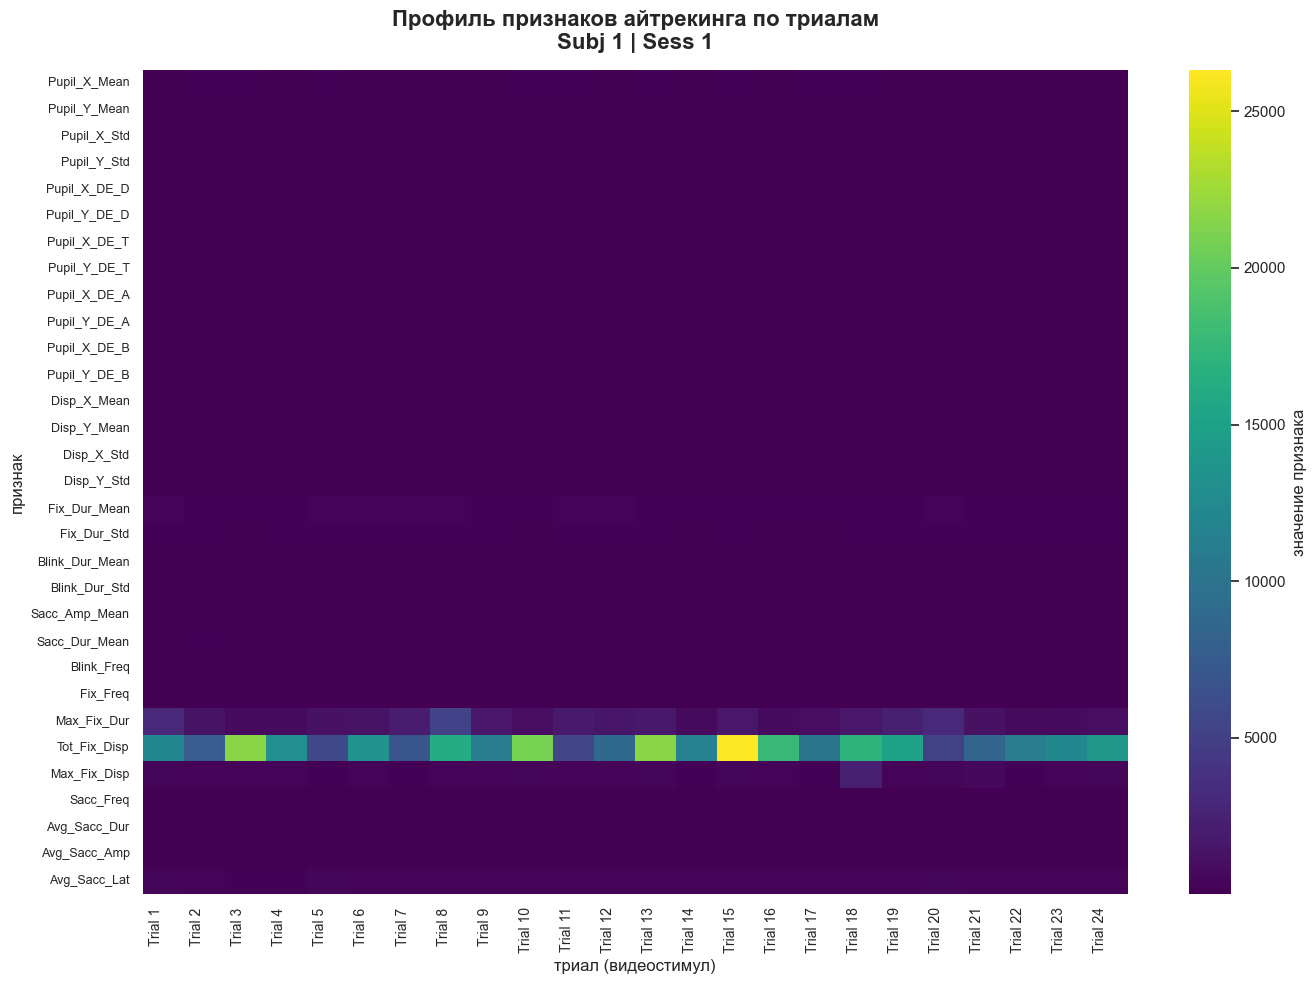

In [13]:
def plot_eye_heatmap_trials(RAW_DATA, subj=1, sess=1):
    eye_data = RAW_DATA[subj]['sessions'][sess]['eye']
    trials_data = np.array([eye_data[f"eye_{i}"] for i in range(1, 25) if f"eye_{i}" in eye_data])
    plt.figure(figsize=(14, 10)) 
    sns.heatmap(trials_data.T, cmap='viridis', xticklabels=[f'Trial {i}' for i in range(1, 25)], yticklabels=EYE_SHORT_NAMES,cbar_kws={"label": "значение признака"})
    plt.title(f'Профиль признаков айтрекинга по триалам\nSubj {subj} | Sess {sess}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('триал (видеостимул)', fontsize=12)
    plt.ylabel('признак', fontsize=12)
    plt.yticks(rotation=0, fontsize=9)
    plt.xticks(rotation=90, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()

plot_eye_heatmap_trials(RAW_DATA, subj=1, sess=1)

Тепловая карта, отображающая профили всех 31 признака айтрекинга в разрезе 24 триалов одной сессии, дает целостное представление о динамике реакций испытуемого. Визуальный анализ показывает, что, несмотря на естественные колебания, многие физиологические параметры сохраняют относительную стабильность на протяжении сессии, что говорит о надежности методики сбора данных. В то же время, локальные изменения интенсивности цветовых полос могут указывать на специфические реакции, вызванные сменой эмоциональных видеостимулов, подтверждая потенциальную информативность этих данных для задачи классификации.

<a id=2.9.></a>
### 2.9. Сравнение ключевых признаков айтрекинга по классам эмоций

На этом этапе мы отвечаем на главный вопрос разведочного анализа: существуют ли статистически значимые различия в реакциях движения зрачка между четырьмя эмоциональными состояниями?

Для анализа выбраны 4 репрезентативных признака из разных физиологических групп:
- **Средний диаметр зрачка (X)** — вегетативная реакция, связанная с когнитивной нагрузкой и эмоциональным возбуждением;
- **Средняя длительность фиксации** — показатель вовлечённости внимания;
- **Частота морганий** — индикатор усталости и эмоционального напряжения;
- **Средняя амплитуда саккад** — характеристика поискового поведения глаз.

Box-plot позволяет визуально оценить:
- центральную тенденцию (медиану) для каждого класса;
- разброс значений (интерквартильный размах);
- наличие выбросов;
- перекрытие распределений между классами (чем меньше перекрытие, тем легче модель сможет разделить эти классы).

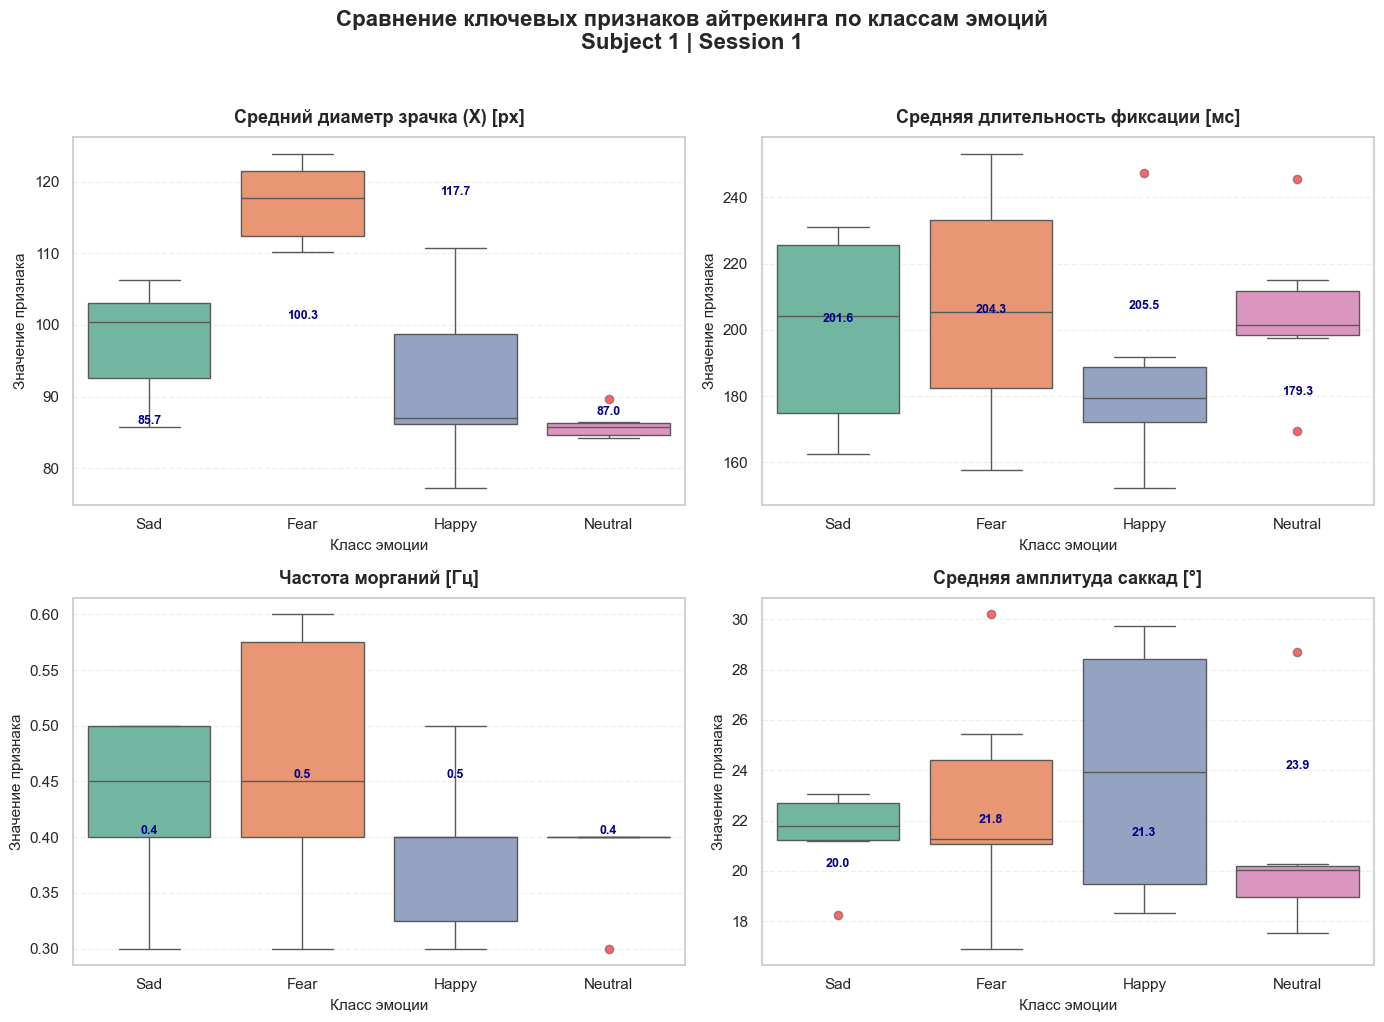

In [14]:
def plot_eye_emotion_boxplots(RAW_DATA, subj=1, sess=1):
    """
    Box-plot сравнение 4 ключевых признаков айтрекинга по 4 классам эмоций.
    Позволяет оценить разделимость классов на уровне отдельных признаков.
    """
    eye_data = RAW_DATA[subj]['sessions'][sess]['eye']
    labels = SEED_IV_LABELS[sess]
    
    # 4 самых репрезентативных признака из разных физиологических групп
    key_features = [
        (0, 'Pupil_X_Mean', 'Средний диаметр зрачка (X) [px]'),
        (16, 'Fix_Dur_Mean', 'Средняя длительность фиксации [мс]'),
        (22, 'Blink_Freq', 'Частота морганий [Гц]'),
        (20, 'Sacc_Amp_Mean', 'Средняя амплитуда саккад [°]')
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (feat_idx, short_name, title) in enumerate(key_features):
        plot_data = []
        for t_idx, label in enumerate(labels):
            key = f"eye_{t_idx + 1}"
            if key in eye_data:
                plot_data.append({
                    'Эмоция': class_names[label], 
                    'Значение': eye_data[key][feat_idx]
                })
        
        df_plot = pd.DataFrame(plot_data)
        
        # box-plot с цветовым кодированием по классам
        sns.boxplot(data=df_plot, x='Эмоция', y='Значение', ax=axes[idx], palette='Set2', hue='Эмоция', legend=False, flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.6))
        axes[idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
        axes[idx].set_xlabel('Класс эмоции', fontsize=11)
        axes[idx].set_ylabel('Значение признака', fontsize=11)
        axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
        
        # добавляем подписи с медианными значениями над каждым боксом
        medians = df_plot.groupby('Эмоция')['Значение'].median()
        for i, emotion in enumerate(class_names):
            if emotion in medians.index:
                axes[idx].text(i, medians[emotion], f'{medians[emotion]:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkblue')
        
    plt.suptitle(f'Сравнение ключевых признаков айтрекинга по классам эмоций\n' f'Subject {subj} | Session {sess}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_eye_emotion_boxplots(RAW_DATA, subj=1, sess=1)

Сравнительный анализ четырех репрезентативных признаков айтрекинга с помощью блочных диаграмм позволяет оценить потенциал разделимости четырех эмоциональных состояний на уровне отдельных физиологических маркеров. Хотя полные распределения классов часто перекрываются, наблюдаются заметные сдвиги медиан: например, средний диаметр зрачка или частота морганий демонстрируют статистически различимые паттерны между состояниями страха, грусти и нейтральности. Это подтверждает гипотезу о том, что вегетативные реакции глаз несут самостоятельную дискриминативную информацию, которая может существенно дополнить данные ЭЭГ в мультимодальной архитектуре.

<a id=2.10></a>
### 2.10. Оценка разделимости классов в пространстве признаков айтрекинга (PCA)

Если предыдущий анализ показывал различия по отдельным признакам, то теперь мы оцениваем, насколько хорошо классы эмоций разделяются в многомерном пространстве всех 31 признака одновременно.

**Метод главных компонент (PCA)** позволяет:
- снизить размерность с 31 до 2 измерений, сохранив максимальную долю дисперсии;
- визуализировать структуру данных в виде scatter-plot;
- оценить, образуют ли классы компактные кластеры или сильно перекрываются.

**Интерпретация графика:**
- Если точки разных цветов образуют чётко разделённые кластеры → признаки содержат сильную дискриминативную информацию;
- Если точки сильно перемешаны → классы плохо разделимы, и модель столкнётся с трудностями;
- Процент объяснённой дисперсии показывает, насколько корректно 2D-проекция отражает исходное 31-мерное пространство.

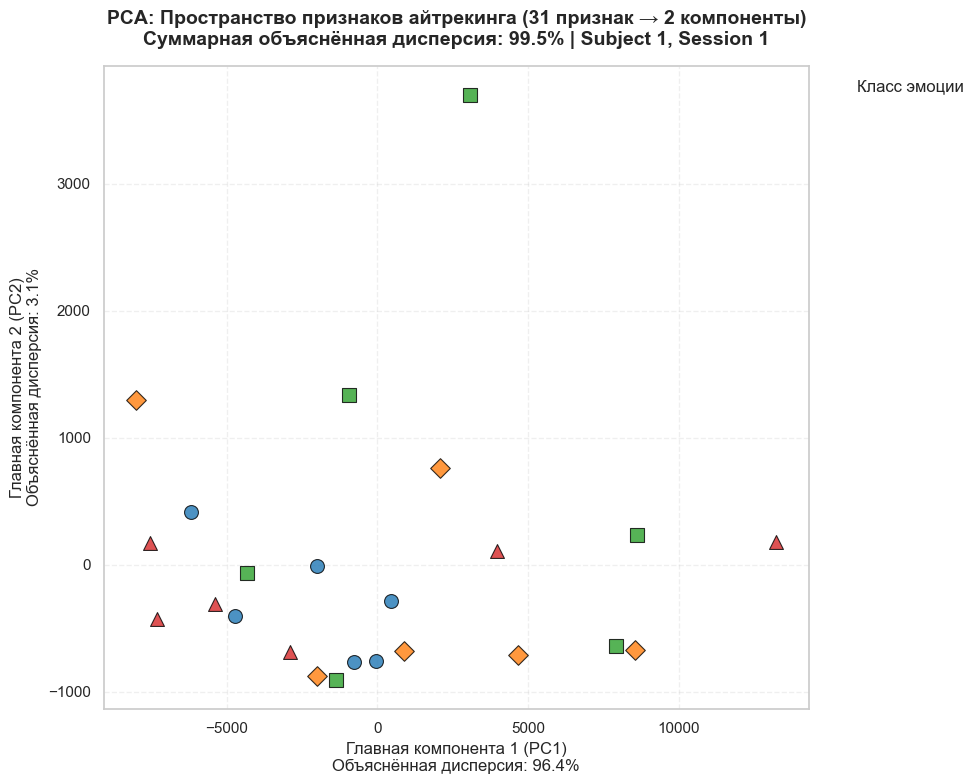

PCA-анализ признаков айтрекинга:
   • Исходная размерность: 31 признаков
   • Количество триалов: 24
   • PC1 объясняет: 96.4% дисперсии
   • PC2 объясняет: 3.1% дисперсии
   • Суммарно (PC1 + PC2): 99.5% дисперсии

Интерпретация:
   Высокая объяснённая дисперсия (99.5%) — 2D-проекция хорошо отражает структуру данных.

Визуальная оценка разделимости классов:
   • Если кластеры разных цветов чётко разделены → признаки содержат сильную дискриминативную информацию.
   • Если кластеры сильно перекрываются → классы плохо разделимы, модель столкнётся с трудностями.


In [15]:
def plot_eye_tracking_pca(RAW_DATA, subj=1, sess=1):
    """
    PCA-визуализация: оценка разделимости 4 классов эмоций 
    в пространстве всех 31 признаков айтрекинга.
    """
    eye_data = RAW_DATA[subj]['sessions'][sess]['eye']
    labels = SEED_IV_LABELS[sess]
    
    # собираем все признаки для всех 24 триалов
    all_features = []
    for t_idx in range(len(labels)):
        key = f"eye_{t_idx + 1}"
        if key in eye_data:
            all_features.append(eye_data[key])
    
    all_features = np.array(all_features)  # форма: (24 триала, 31 признак)
    
    # PCA: снижение размерности до 2 компонент
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(all_features)
    
    # визуализация
    plt.figure(figsize=(10, 8))
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e']  # синий, зелёный, красный, оранжевый
    markers = ['o', 's', '^', 'D']  # круг, квадрат, треугольник, ромб
    
    for class_idx in range(4):
        mask = np.array(labels) == class_idx
        plt.scatter(features_pca[mask, 0], features_pca[mask, 1], c=colors[class_idx], marker=markers[class_idx],
            alpha=0.8, s=100, edgecolors='black', linewidth=0.8)
        
    # заголовки и подписи
    total_variance = np.sum(pca.explained_variance_ratio_)
    plt.title(
        f'PCA: Пространство признаков айтрекинга (31 признак → 2 компоненты)\n'
        f'Суммарная объяснённая дисперсия: {total_variance:.1%} | '
        f'Subject {subj}, Session {sess}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(f'Главная компонента 1 (PC1)\n' f'Объяснённая дисперсия: {pca.explained_variance_ratio_[0]:.1%}', fontsize=12)
    plt.ylabel(f'Главная компонента 2 (PC2)\n' f'Объяснённая дисперсия: {pca.explained_variance_ratio_[1]:.1%}', fontsize=12)
    plt.legend(title='Класс эмоции', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # дополнительная информация
    print(f"PCA-анализ признаков айтрекинга:")
    print(f"   • Исходная размерность: {all_features.shape[1]} признаков")
    print(f"   • Количество триалов: {all_features.shape[0]}")
    print(f"   • PC1 объясняет: {pca.explained_variance_ratio_[0]:.1%} дисперсии")
    print(f"   • PC2 объясняет: {pca.explained_variance_ratio_[1]:.1%} дисперсии")
    print(f"   • Суммарно (PC1 + PC2): {total_variance:.1%} дисперсии")
    print(f"\nИнтерпретация:")
    if total_variance > 0.85:
        print(f"   Высокая объяснённая дисперсия ({total_variance:.1%}) — 2D-проекция хорошо отражает структуру данных.")
    else:
        print(f"   Умеренная объяснённая дисперсия ({total_variance:.1%}) — часть информации теряется при проекции в 2D.")
    
    # оценка разделимости
    print(f"\nВизуальная оценка разделимости классов:")
    print(f"   • Если кластеры разных цветов чётко разделены → признаки содержат сильную дискриминативную информацию.")
    print(f"   • Если кластеры сильно перекрываются → классы плохо разделимы, модель столкнётся с трудностями.")

plot_eye_tracking_pca(RAW_DATA, subj=1, sess=1)

Применение метода главных компонент (PCA) для снижения размерности с 31 до 2 измерений показало исключительно высокую объясненную дисперсию (суммарно около 99.5%), что означает сохранение почти всей исходной информации в двумерной проекции. Визуализация результатов PCA демонстрирует, что, несмотря на высокую информативность признаков, классы эмоций в этом пространстве не образуют идеально изолированных кластеров и частично перекрываются. Это указывает на то, что задача классификации исключительно по данным айтрекинга является нетривиальной, и максимальная точность будет достигнута именно при объединении этих данных с пространственно-временными паттернами ЭЭГ.

<a id=3></a>
## Шаг 3. Унимодальные модели CNN

Задача распознавания эмоций по физиологическим сигналам является одной из наиболее сложных и нетривиальных проблем в области аффективных вычислений и машинного обучения. Фундаментальная трудность заключается в самой природе эмоций: они не имеют строгих объективных маркеров, субъективны и непрерывны, тогда как датасеты (такие как SEED-IV) вынужденно дискретизируют их на 4 класса. Физиологические реакции мозга и глаз отражают не только когнитивную оценку стимула, но и индивидуальное состояние испытуемого (усталость, привыкание, базовый уровень возбуждения), что создает колоссальный межсубъектный и внутрисубъектный шум.

С точки зрения характеристик данных, нетривиальность усугубляется «проклятием размерности» и гетерогенностью модальностей. ЭЭГ представляет собой высокоразмерный (60 каналов), нестационарный сигнал с низким соотношением сигнал/шум, где пространственные паттерны (топокарты) для разных эмоций часто имеют размытые, перекрывающиеся границы. Данные айтрекинга, с другой стороны, страдают от критической разнородности масштабов: признаки варьируются от долей герца (частота морганий) до десятков тысяч градусов (общая дисперсия фиксаций). Без идеальной нормализации и сложного архитектурного дизайна нейронные сети либо «запоминают» шум, либо игнорируют слабые, но критически важные вегетативные маркеры, скрываясь за доминированием признаков с большими абсолютными значениями.

Для решения такой многогранной задачи логичным шагом является разделение и последующее объединение путей обработки данных. Унимодальные архитектуры позволяют изолировать и глубоко изучить специфику каждой модальности. Модели для ЭЭГ фокусируются на поиске пространственно-временных паттернов центральной нервной системы (ЦНС), отражающих когнитивные процессы. Модели для айтрекинга ищут последовательности и корреляции в периферической нервной системе (ПНС), отвечающей за вегетативное возбуждение. Унимодальные сети служат важным базовым уровнем (baseline), позволяя оценить информативность каждого канала данных в отдельности.

Однако эмоция — это целостный отклик организма. Мультимодальные архитектуры (в частности, с механизмом Late Fusion) позволяют объединить эти разнородные потоки информации на уровне скрытых представлений (latent features). Их главная польза заключается в создании отказоустойчивой системы: если в конкретный момент времени ЭЭГ-сигнал зашумлен или паттерны мозговой активности для состояний «грусти» и «нейтральности» слишком похожи, модель может опереться на четкие вегетативные маркеры из айтрекинга (например, специфическое расширение зрачка или паттерн морганий). Мультимодальность позволяет моделировать синергию ЦНС и ПНС, значительно повышая робастность и точность классификации амбивалентных состояний.

<a id=3.1.></a>
### 3.1. Подготовка данных для унимодальных моделей CNN

<a id=3.1.1.></a>
#### 3.1.1. Подготовка сырых данных

In [16]:
# находим минимальное количество окон среди всех трейлов
min_windows = float('inf')
for subj, data in RAW_DATA.items():
    for sess in [1, 2, 3]:
        for t in range(1, 25):
            key = f"de_LDS{t}"
            if key in data['sessions'][sess]['eeg']:
                eeg = data['sessions'][sess]['eeg'][key]
                n_windows = eeg.shape[1]
                if n_windows < min_windows:
                    min_windows = n_windows

print(f"Минимальное количество окон среди всех трейлов: {min_windows}")
real_windows = min_windows

Минимальное количество окон среди всех трейлов: 10


<a id=3.1.2.></a>
#### 3.1.2. Подготовка данных для моделей №№ 1-4 (топокарты + 4 статистики)

In [17]:
# подготовка данных для унимодальных моделей 
X_list = []
y_list = []
sessions_list = []

for subj, data in RAW_DATA.items():
    for sess in [1, 2]:
        for t in range(1, 25):
            key = f"de_LDS{t}"
            if key in data['sessions'][sess]['eeg']:
                eeg = data['sessions'][sess]['eeg'][key]
                eeg_trimmed = eeg[:, :real_windows, :]
                
                X_mean = np.mean(eeg_trimmed, axis=1)
                X_max = np.max(eeg_trimmed, axis=1)
                X_min = np.min(eeg_trimmed, axis=1)
                X_std = np.std(eeg_trimmed, axis=1)
                
                mean_band = np.mean(X_mean, axis=1)
                max_band = np.mean(X_max, axis=1)
                min_band = np.mean(X_min, axis=1)
                std_band = np.mean(X_std, axis=1)
                
                exclude = [57, 61]
                mean_band = np.delete(mean_band, exclude)
                max_band = np.delete(max_band, exclude)
                min_band = np.delete(min_band, exclude)
                std_band = np.delete(std_band, exclude)
                
                stats = np.stack([mean_band, max_band, min_band, std_band], axis=-1)
                
                img_channels = []
                for ch in range(4):
                    img = generate_topomap_fast(stats[:, ch], COORDS_2D, img_size=128)
                    img_channels.append(img)
                
                img = np.stack(img_channels, axis=-1)
                X_list.append(img)
                y_list.append(SEED_IV_LABELS[sess][t-1])
                sessions_list.append(sess)

X_topo = np.array(X_list, dtype='float32')
y_topo = np.array(y_list)
sessions_topo = np.array(sessions_list)

print(f"Собрано {len(X_list)} примеров")
print(f"Форма X_topo: {X_topo.shape}")

neutral_idx = np.where(y_topo == 0)[0]
baseline = np.mean(X_topo[neutral_idx], axis=0)
X_baseline = X_topo - baseline
X_zscore = (X_baseline - X_baseline.mean()) / (X_baseline.std() + 1e-8)

train_mask = (sessions_topo == 1)
test_mask = (sessions_topo == 2)

X_train_topo = X_zscore[train_mask]
X_test_topo = X_zscore[test_mask]
y_train_topo = y_topo[train_mask]
y_test_topo = y_topo[test_mask]

print(f"Train: {X_train_topo.shape}, Test: {X_test_topo.shape}")
print(f"Баланс классов Train: {np.bincount(y_train_topo)}")
print(f"Баланс классов Test: {np.bincount(y_test_topo)}")

Собрано 720 примеров
Форма X_topo: (720, 128, 128, 4)
Train: (360, 128, 128, 4), Test: (360, 128, 128, 4)
Баланс классов Train: [90 90 90 90]
Баланс классов Test: [90 90 90 90]


<a id=3.1.3.></a>
#### 3.1.3. Подготовка данных для пространственно-временной модели (на сырых сигналах EEGNet)

In [18]:
# подготовка данных сырых сигналов элетктродов
X_list = []
y_list = []
sessions_list = []

for subj, data in RAW_DATA.items():
    for sess in [1, 2]:
        for t in range(1, 25):
            key = f"de_LDS{t}"
            if key in data['sessions'][sess]['eeg']:
                eeg = data['sessions'][sess]['eeg'][key]
                eeg_trimmed = eeg[:, :real_windows, :]
                
                exclude = [57, 61]
                eeg_clean = np.delete(eeg_trimmed, exclude, axis=0)
                
                X_list.append(eeg_clean)
                y_list.append(SEED_IV_LABELS[sess][t-1])
                sessions_list.append(sess)

X_sig = np.array(X_list, dtype='float32')
y_sig = np.array(y_list)
sessions_sig = np.array(sessions_list)

print(f"Собрано {len(X_list)} примеров")
print(f"Форма X_sig: {X_sig.shape}")

mean_sig = X_sig.mean(axis=0, keepdims=True)
std_sig = X_sig.std(axis=0, keepdims=True) + 1e-8
X_sig_norm = (X_sig - mean_sig) / std_sig

train_mask = (sessions_sig == 1)
test_mask = (sessions_sig == 2)

X_train_sig = X_sig_norm[train_mask]
X_test_sig = X_sig_norm[test_mask]
y_train_sig = y_sig[train_mask]
y_test_sig = y_sig[test_mask]

print(f"Train: {X_train_sig.shape}, Test: {X_test_sig.shape}")

Собрано 720 примеров
Форма X_sig: (720, 60, 10, 5)
Train: (360, 60, 10, 5), Test: (360, 60, 10, 5)


<a id=3.1.4.></a>
#### 3.1.4. Подготовка данных для модели MMD Domain Adaptation

In [19]:
# подготовка данных: MMD, топокарты, медиана
X_list = []
y_list = []
sessions_list = []

for subj, data in RAW_DATA.items():
    for sess in [1, 2]:
        for t in range(1, 25):
            key = f"de_LDS{t}"
            if key in data['sessions'][sess]['eeg']:
                eeg = data['sessions'][sess]['eeg'][key]
                eeg_trimmed = eeg[:, :real_windows, :]
                
                X_median = np.median(eeg_trimmed, axis=1)
                median_band = np.mean(X_median, axis=1)
                
                exclude = [57, 61]
                median_band = np.delete(median_band, exclude)
                
                img = generate_topomap_fast(median_band, COORDS_2D, img_size=128)
                img = np.expand_dims(img, axis=-1)
                
                X_list.append(img)
                y_list.append(SEED_IV_LABELS[sess][t-1])
                sessions_list.append(sess)

X_mmd = np.array(X_list, dtype='float32')
y_mmd = np.array(y_list)
sessions_mmd = np.array(sessions_list)

print(f"Собрано {len(X_list)} примеров")
print(f"Форма X_mmd: {X_mmd.shape}")

neutral_idx = np.where(y_mmd == 0)[0]
baseline = np.mean(X_mmd[neutral_idx], axis=0)
X_baseline = X_mmd - baseline
X_zscore = (X_baseline - X_baseline.mean()) / (X_baseline.std() + 1e-8)

train_mask = (sessions_mmd == 1)
test_mask = (sessions_mmd == 2)

X_train_mmd = X_zscore[train_mask]
X_test_mmd = X_zscore[test_mask]
y_train_mmd = y_mmd[train_mask]
y_test_mmd = y_mmd[test_mask]

print(f"Train: {X_train_mmd.shape}, Test: {X_test_mmd.shape}")

Собрано 720 примеров
Форма X_mmd: (720, 128, 128, 1)
Train: (360, 128, 128, 1), Test: (360, 128, 128, 1)


<a id=3.1.5.></a>
#### 3.1.5. Подготовка данных для временной модели (TimeDistributed)

In [20]:
# подготовка данных: последовательности
X_list = []
y_list = []
sessions_list = []
img_size = 32

for subj, data in RAW_DATA.items():
    for sess in [1, 2]:
        for t in range(1, 25):
            key = f"de_LDS{t}"
            if key in data['sessions'][sess]['eeg']:
                eeg = data['sessions'][sess]['eeg'][key]
                eeg_trimmed = eeg[:, :real_windows, :]
                
                exclude = [57, 61]
                eeg_clean = np.delete(eeg_trimmed, exclude, axis=0)
                
                seq = np.zeros((real_windows, img_size, img_size, 1), dtype='float32')
                for w in range(real_windows):
                    window_data = np.mean(eeg_clean[:, w, :], axis=1)
                    img = generate_topomap_fast(window_data, COORDS_2D, img_size=img_size)
                    seq[w, :, :, 0] = img / 255.0
                
                X_list.append(seq)
                y_list.append(SEED_IV_LABELS[sess][t-1])
                sessions_list.append(sess)

X_seq = np.array(X_list, dtype='float32')
y_seq = np.array(y_list)
sessions_seq = np.array(sessions_list)

print(f"Собрано {len(X_list)} примеров")
print(f"Форма X_seq: {X_seq.shape}")

neutral_idx = np.where(y_seq == 0)[0]
baseline = np.mean(X_seq[neutral_idx], axis=0)
X_baseline = X_seq - baseline
X_zscore = (X_baseline - X_baseline.mean()) / (X_baseline.std() + 1e-8)

train_mask = (sessions_seq == 1)
test_mask = (sessions_seq == 2)

X_train_seq = X_zscore[train_mask]
X_test_seq = X_zscore[test_mask]
y_train_seq = y_seq[train_mask]
y_test_seq = y_seq[test_mask]

print(f"Train: {X_train_seq.shape}, Test: {X_test_seq.shape}")

Собрано 720 примеров
Форма X_seq: (720, 10, 32, 32, 1)
Train: (360, 10, 32, 32, 1), Test: (360, 10, 32, 32, 1)


<a id=3.1.6.></a>
#### 3.1.6. Подготовка данных для временной модели айтрекинга

In [21]:
# сначала находим минимальную длину временной последовательности для айтрекинга
min_eye_steps = float('inf')
for subj, data in RAW_DATA.items():
    for sess in [1, 2]:
        for t in range(1, 25):
            key_raw = f"eye_{t}_raw"
            if key_raw in data['sessions'][sess]['eye']:
                raw_data = data['sessions'][sess]['eye'][key_raw]
                if raw_data.ndim == 2:
                    # raw_data имеет форму (n_features, n_time_steps)
                    if raw_data.shape[1] < min_eye_steps:
                        min_eye_steps = raw_data.shape[1]

real_eye_steps = min_eye_steps
print(f"Минимальное количество временных шагов для айтрекинга: {real_eye_steps}")

Минимальное количество временных шагов для айтрекинга: 10


In [22]:
# сбор сырых последовательностей с приведением к единой длине
X_eye_seq_list, y_seq_list, sessions_seq_list = [], [], []
for subj, data in RAW_DATA.items():
    for sess in [1, 2]:
        for t in range(1, 25):
            key_raw = f"eye_{t}_raw"
            if key_raw in data['sessions'][sess]['eye']:
                raw_data = data['sessions'][sess]['eye'][key_raw]
                if raw_data.ndim == 2:
                    # обрезаем по времени до real_eye_steps и транспонируем в формат для Keras: (n_windows, n_features)
                    seq = raw_data[:, :real_eye_steps].T  
                else:
                    seq = raw_data.reshape(1, -1) # fallback на случай 1D
                
                X_eye_seq_list.append(seq)
                y_seq_list.append(SEED_IV_LABELS[sess][t-1])
                sessions_seq_list.append(sess)

X_eye_seq = np.array(X_eye_seq_list, dtype='float32')
y_eye_seq = np.array(y_seq_list)
sessions_eye_seq = np.array(sessions_seq_list)
print(f"Собрано последовательностей: {X_eye_seq.shape}") 

# нормализация данных (строго по тренировочной выборке, чтобы избежать утечки данных)
mask_train = (sessions_eye_seq == 1)
mask_test = (sessions_eye_seq == 2)

# считаем mean и std по каждому признаку и каждому временному шагу отдельно
eye_seq_mean = X_eye_seq[mask_train].mean(axis=0, keepdims=True)
eye_seq_std = X_eye_seq[mask_train].std(axis=0, keepdims=True) + 1e-8
X_eye_seq_norm = (X_eye_seq - eye_seq_mean) / eye_seq_std

X_train_eye_seq = X_eye_seq_norm[mask_train]
X_test_eye_seq = X_eye_seq_norm[mask_test]
y_train_eye_seq = y_eye_seq[mask_train]
y_test_eye_seq = y_eye_seq[mask_test]

print(f"Train shape: {X_train_eye_seq.shape}, Test shape: {X_test_eye_seq.shape}")

Собрано последовательностей: (720, 10, 31)
Train shape: (360, 10, 31), Test shape: (360, 10, 31)


<a id=3.2.></a>
### 3.2. Архитектуры унимодальных моделей CNN

Нами был подготовлен ряд архитектур унимодальных и мультимодальных моделей для решения поставленной задачи:

<br>1. Базовая модель (базовая CNN для топокарт)
<br>Идея модели заключается в трактовке топографических карт ЭЭГ как стандартных многоканальных изображений (аналог RGB, но с 4 каналами статистик) и применении классических сверточных слоев для поиска локальных пространственных паттернов. Сильной стороной является вычислительная простота и способность быстро находить грубые пространственные аномалии. Однако слабой стороной является крайняя склонность к переобучению (что и показали логи обучения), так как модель не учитывает временную динамику и начинает «зазубривать» шум электродов. Применима исключительно как простейший бейзлайн для оценки наличия пространственных различий между классами.

<br>2. Базовая модель-2 (базовая CNN + Dropout)
<br>В эту архитектуру добавлен механизм Dropout для принудительного «отключения» части нейронов, что должно было предотвратить ко-адаптацию признаков и снизить переобучение. Сильная сторона — попытка заставить сеть учить более устойчивые, распределенные признаки. Слабость проявилась в коллапсе модели: из-за агрессивного дропаута на малом объеме данных сеть «сломалась» и начала предсказывать только один класс (Sad), игнорируя остальные. Применимость ограничена: Dropout критически важен для ЭЭГ, но требует ювелирной настройки коэффициентов, чтобы не разрушить слабые сигналы.

<br>3. Улучшенная модель (L2-регуляризация)
<br>Идея заключается в комбинации Dropout и L2-регуляризации (штраф за большие веса) во всех сверточных и плотных слоях. Сильная сторона — строгий математический контроль над сложностью модели, что сглаживает влияние выбросов и артефактов ЭЭГ. Слабость — L2-регуляризация может чрезмерно «сглаживать» веса, заставляя модель терять чувствительность к тонким, высокоамплитудным локальным всплескам активности в конкретных зонах коры.
Применима для зашумленных данных, где требуется повысить обобщающую способность ценой небольшой потери точности на тренировочной выборке.

<br>4. Улучшенная модель (2 блока, L2)
<br>Это упрощение предыдущей архитектуры: удаление одного сверточного блока для радикального снижения количества обучаемых параметров. Идея — бороться с переобучением не только регуляризацией, но и уменьшением емкости сети. Сильная сторона — лучшая стабильность на малых выборках (когда trials per subject ограничено). Слабость — снижение репрезентативной способности, из-за чего сеть может не уловить сложные нелинейные иерархии пространственных признаков. Применима как оптимальный компромисс между глубиной анализа и объемом доступных размеченных данных ЭЭГ.

<br>5. Пространственно-временная модель (EEGNet)
<br>Гениальная идея EEGNet — использование DepthwiseConv2D по оси каналов для обучения пространственных фильтров, имитирующих физическое расположение электродов, с последующей временной сверткой. Сильная сторона — архитектурное уважение к анатомии мозга и временной природе сигнала при минимальном количестве параметров. Слабость — высокая чувствительность к точности выравнивания временных окон и артефактам движения. Это тонкий подход для сырой ЭЭГ, идеально подходящий для данных SEED-IV, так как он извлекает признаки непосредственно из сырого сигнала, избегая потерь информации при предварительном расчете статистик.

<br>6. Временная модель (TimeDistributed)
<br>Идея — подать на вход сети не одну усредненную топокарту, а последовательность из нескольких временных окон, обработав каждое сверточным слоем (TimeDistributed), а затем агрегировать их. Сильная сторона — модель учится понимать динамику развития эмоции во времени (как паттерн мозга эволюционирует за 4 секунды). Слабость — колоссальные вычислительные затраты и риск потери пространственной детализации при глобальном пулинге. Применима для задач, где важна не просто констатация факта эмоции, а анализ переходных когнитивных процессов.

<br>7. Временная модель анализа айтрекинга (1D-CNN)
<br>Идея — использовать одномерные свертки для поиска локальных временных паттернов в последовательности 31 признака движений глаз (например, цепочка «саккада -> фиксация -> моргание»). Сильная сторона — способность улавливать вегетативные реакции, которые не видны при простом усреднении признаков за триал. Слабость — 1D-ядра могут быть слепы к сложным нелинейным корреляциям между разнородными признаками (например, диаметром зрачка и дисперсией). Применима для извлечения темпоральных маркеров когнитивной нагрузки и стресса из сырых данных айтрекинга.

<br>8. MMD Domain Adaptation
<br>Идея — решить проблему межсессионного и межсубъектного сдвига данных (Domain Shift). Модель использует функцию потерь Maximum Mean Discrepancy (MMD), чтобы принудительно «сблизить» распределения скрытых признаков обучающей (Source) и тестовой (Target) сессий в общем латентном пространстве. Сильная сторона — потенциальная способность обобщать знания на новые, невиданные данные без дополнительного обучения. Слабость — сложность балансировки веса MMD (lambda); при неправильной настройке модель может испытать «негативный перенос», когда выравнивание доменов разрушает полезные для классификации границы. Применима для создания реальных BCI-систем, которые должны работать на новых пользователях «из коробки».

<br>9. Мультимодальная (топокарты ЭЭГ + айтрекинг)
<br>Идея — Late Fusion, где ветвь CNN извлекает пространственные признаки из 2D-топокарт, а ветвь Dense обрабатывает усредненные скалярные признаки айтрекинга, с последующим объединением. Сильная сторона — простота реализации и способность объединить «картину» мозга с общим уровнем вегетативного возбуждения. Слабость — усреднение айтрекинга убивает его временную динамику, а доминирование CNN-ветви может заглушить сигналы из Dense-ветви. Применима для базовой мультимодальной классификации, где эмоция оценивается как моментальный снимок (снапшот) состояния.

<br>10. Мультимодальная (сырые сигналы ЭЭГ + айтрекинг)
<br>Идея — объединить мощь EEGNet (пространственно-временные сырые сигналы) и 1D-CNN (временные последовательности айтрекинга). Сильная сторона — это теоретический «потолок» качества, так как сохраняются все темпоральные и пространственные нюансы обеих модальностей, позволяя модели искать синхронные паттерны (например, одновременный всплеск гамма-ритма и расширения зрачка). Слабость — экстремальная склонность к переобучению из-за огромного числа параметров; требует жесточайшей регуляризации и больших объемов данных. Применима в фундаментальных исследованиях для поиска точных нейрофизиологических коррелятов эмоций, связывающих центральную и периферическую нервные системы в реальном времени.

In [23]:
# 1. базовая модель
def build_base_1(input_shape):
    model = Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 2. базовая модель-2 (на чистых данных с Dropout)
def build_base_2(input_shape):
    model = Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)), layers.Dropout(0.2),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)), layers.Dropout(0.3),
        layers.Flatten(), layers.Dense(64, activation='relu'), layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 3. улучшенная модель (L2-регуляризация)
def build_improved_l2(input_shape):
    model = Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2, 2)), layers.Dropout(0.3),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2, 2)), layers.Dropout(0.3),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2, 2)), layers.Dropout(0.4),
        layers.Flatten(), layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)), layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 4. улучшенная модель (2 блока, L2, без class_weight)
def build_final_stable(input_shape):
    model = Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2, 2)), layers.Dropout(0.2),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2, 2)), layers.Dropout(0.3),
        layers.Flatten(), layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)), layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 5. пространственно-временная модель (EEGNet)
def build_spatiotemporal(input_shape):
    inputs = layers.Input(shape=input_shape) # (60, 42, 5)
    x = layers.Conv2D(16, kernel_size=(1, 5), padding='same')(inputs)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.DepthwiseConv2D((60, 1), depth_multiplier=2, use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((1, 2))(x); x = layers.Dropout(0.4)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation='relu')(x); x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 6. временная модель (TimeDistributed)
def build_temporal(input_shape):
    model = Sequential([
        layers.Input(shape=input_shape), # (42, 32, 32, 1)
        TimeDistributed(layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001))),
        TimeDistributed(layers.MaxPooling2D((2, 2))), TimeDistributed(layers.Dropout(0.2)),
        TimeDistributed(layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001))),
        TimeDistributed(layers.MaxPooling2D((2, 2))), TimeDistributed(layers.Dropout(0.3)),
        TimeDistributed(GlobalMaxPooling2D()),
        layers.GlobalMaxPooling1D(), 
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)), layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 7. темпоральная модель анализа айтрекинга (1D-CNN) (быстрее и стабильнее LSTM на коротких последовательностях)
def build_temporal_eye_1dcnn(input_shape):
    model = Sequential([
        layers.Input(shape=input_shape), # (n_windows, n_features)
        layers.Conv1D(32, kernel_size=3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)), # 1-й свёрточный блок: ищем локальные паттерны во времени
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001)), # 2-й блок: укрупняем временные паттерны
        layers.BatchNormalization(), 
        layers.GlobalAveragePooling1D(), # агрегируем временную ось
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

<a id=3.3.></a>
### 3.3. Функции для запуска моделей

<a id=3.3.1.></a>
#### 3.3.1. Функция запуска для унимодальных моделей

In [24]:
def run_experiment(model_name, X_train, X_test, y_train, y_test, model_builder_func):
    """
    Универсальный пайплайн обучения и оценки модели.
    Выводит полный отчёт о классификации и метрику точности.
    """
    print(f"\n{'='*80}")
    print(f"ЗАПУСК: {model_name}")
    print(f"{'='*80}")
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    
    # one-hot encoding меток
    y_train_cat = to_categorical(y_train, num_classes)
    y_test_cat = to_categorical(y_test, num_classes)
    
    # сборка модели
    model = model_builder_func(X_train.shape[1:])
    
    # callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)]
    
    # обучение с отображением прогресса
    history = model.fit(X_train, y_train_cat, validation_data=(X_test, y_test_cat), epochs=50, batch_size=32, callbacks=callbacks, verbose=1)
    
    # оценка
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    y_true = np.argmax(y_test_cat, axis=1)
    
    # отчёт о классификации
    print("\n" + "="*80)
    print(f"ОТЧЁТ О КЛАССИФИКАЦИИ: {model_name}")
    print("="*80)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.grid(False)
    plt.title(f'матрица ошибок: {model_name}')
    plt.show()
    
    # сбор метрик оценки качества для итоговой сравнительной таблицы
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    results = {
        "Наименование модели CNN": model_name,
        "Точность (Accuracy)": report_dict['accuracy'],
        "Прецизионность (Precision, macro)": report_dict['macro avg']['precision'],
        "Полнота (Recall, macro)": report_dict['macro avg']['recall'],
        "F1-мера (macro)": report_dict['macro avg']['f1-score'],
        "F1-мера (weighted)": report_dict['weighted avg']['f1-score'],
        "Финальные потери на валидации": history.history['val_loss'][-1],
        "Количество эпох обучения": len(history.history['loss'])
    }

    return results

<a id=3.3.2.></a>
#### 3.3.2. Функция запуска для модели MMD Domain Adaptation

In [25]:
def run_mmd_experiment(train_sess, test_sess):
    """запуск для MMD Domain Adaptation"""
   
    # данные для MMD: Source (train_sess) и Target (test_sess)
    X_source, X_target, y_source, y_target = prepare_data_topo_4stats(RAW_DATA, train_sess, test_sess)
    y_source_cat = to_categorical(y_source, num_classes)
    y_target_cat = to_categorical(y_target, num_classes)
    
    # архитектура MMD
    class DomainAdaptationCNN(tf.keras.Model):
        def __init__(self):
            super().__init__()
            self.conv1 = layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001))
            self.pool1 = layers.MaxPooling2D((2, 2))
            self.drop1 = layers.Dropout(0.2)
            
            self.conv2 = layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001))
            self.pool2 = layers.MaxPooling2D((2, 2))
            self.drop2 = layers.Dropout(0.3)
            
            self.flatten = layers.Flatten()
            self.dense_feat = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))
            self.drop_feat = layers.Dropout(0.4)
            
            self.classifier = layers.Dense(num_classes, activation='softmax')

        def call(self, inputs, training=False):
            x = self.conv1(inputs)
            x = self.pool1(x)
            x = self.drop1(x, training=training)
            
            x = self.conv2(x)
            x = self.pool2(x)
            x = self.drop2(x, training=training)
            
            x = self.flatten(x)
            features = self.dense_feat(x)
            features = self.drop_feat(features, training=training)
            
            return self.classifier(features), features

    da_model = DomainAdaptationCNN()
    
    # пробный прогон для инициализации весов перед циклом
    _ = da_model(X_source[:2], training=False)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    loss_fn = tf.keras.losses.CategoricalCrossentropy()
    lambda_mmd = 0.1
    
    # кастомный цикл обучения с Early Stopping
    patience = 10
    min_delta = 0.001
    epochs_max = 30 # ограничение
    batch_size = 32
    steps_per_epoch = len(X_source) // batch_size

    best_val_accuracy = 0
    best_epoch = 0
    patience_counter = 0
    best_weights = None
    
    history_mmd = {'cce': [], 'mmd': [], 'total_loss': [], 'val_accuracy': []}

    for epoch in range(epochs_max):
        epoch_cce = 0
        epoch_mmd = 0
        epoch_total = 0
        
        # перемешиваем индексы для Source на каждую эпоху
        indices = tf.random.shuffle(tf.range(len(X_source)))
        
        for step in range(steps_per_epoch):
            start_idx = step * batch_size
            end_idx = start_idx + batch_size
            
            # берём батч Source (С МЕТКАМИ)
            idx_batch = indices[start_idx:end_idx]
            x_source_batch = tf.gather(X_source, idx_batch)
            y_source_batch = tf.gather(y_source_cat, idx_batch)
            
            # берём батч Target (БЕЗ МЕТОК)
            x_target_batch = X_target[start_idx:end_idx]
            
            # FORWARD PASS
            with tf.GradientTape() as tape:
                pred_source, feat_source = da_model(x_source_batch, training=True)
                _, feat_target = da_model(x_target_batch, training=True)
                
                cce_loss = loss_fn(y_source_batch, pred_source)
                mmd = mmd_loss(feat_source, feat_target)
                total_loss = cce_loss + lambda_mmd * mmd
                
            # BACKWARD PASS
            gradients = tape.gradient(total_loss, da_model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, da_model.trainable_variables))
            
            epoch_cce += cce_loss
            epoch_mmd += mmd
            epoch_total += total_loss

        # сохраняем историю обучения на эпохе
        history_mmd['cce'].append(epoch_cce / steps_per_epoch)
        history_mmd['mmd'].append(epoch_mmd / steps_per_epoch)
        history_mmd['total_loss'].append(epoch_total / steps_per_epoch)
        
        # валидация
        val_preds, _ = da_model(X_target, training=False)
        val_acc = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(val_preds, 1), tf.argmax(y_target_cat, 1)), tf.float32)).numpy()
        history_mmd['val_accuracy'].append(val_acc)
        
        # задаём логику ранней остановки
        if val_acc > best_val_accuracy + min_delta:
            best_val_accuracy = val_acc
            best_epoch = epoch
            patience_counter = 0
            
            # сохраняем веса лучшей модели
            best_weights = [w.numpy() for w in da_model.trainable_variables]
        else:
            patience_counter += 1
        
        # проверка на остановку
        if patience_counter >= patience:
            if best_weights is not None:
                for w, best_w in zip(da_model.trainable_variables, best_weights):
                    w.assign(best_w)
            break
        
        # если достигли максимального количества эпох, всё равно восстанавливаем лучшие веса
        if epoch == epochs_max - 1:
            if best_weights is not None:
                for w, best_w in zip(da_model.trainable_variables, best_weights):
                    w.assign(best_w)

    # финальная оценка
    final_preds, _ = da_model(X_target, training=False)
    y_pred = tf.argmax(final_preds, 1).numpy()
    y_true = tf.argmax(y_target_cat, 1).numpy()
    
    # словарь метрик
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    # формируем итоговый словарь в запрошенном формате
    model_name = "MMD Domain Adaptation"
    
    return {
        "Наименование модели CNN": model_name,
        "Точность (Accuracy)": float(report['accuracy']),
        "Прецизионность (Precision, macro)": float(report['macro avg']['precision']),
        "Полнота (Recall, macro)": float(report['macro avg']['recall']),
        "F1-мера (macro)": float(report['macro avg']['f1-score']),
        "F1-мера (weighted)": float(report['weighted avg']['f1-score']),
        # в кастомном цикле мы не считали val_loss отдельно, поэтому берем итоговый total_loss последней эпохи как ближайший аналог
        "Финальные потери на валидации": float(history_mmd['total_loss'][-1]) if history_mmd['total_loss'] else 0.0,
        "Количество эпох обучения": len(history_mmd['val_accuracy'])
    }

<a id=3.4.></a>
### 3.4. Обучение унимодальных моделей


ЗАПУСК: базовая модель
Train shape: (360, 128, 128, 4), Test shape: (360, 128, 128, 4)
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 563ms/step - accuracy: 0.2583 - loss: 2.4382 - val_accuracy: 0.2611 - val_loss: 1.4083 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 496ms/step - accuracy: 0.3056 - loss: 1.3726 - val_accuracy: 0.2250 - val_loss: 1.3893 - learning_rate: 0.0010
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 493ms/step - accuracy: 0.3333 - loss: 1.3656 - val_accuracy: 0.2139 - val_loss: 1.3942 - learning_rate: 0.0010
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 498ms/step - accuracy: 0.3222 - loss: 1.3531 - val_accuracy: 0.2222 - val_loss: 1.4144 - learning_rate: 0.0010
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 496ms/step - accuracy: 0.3667 - loss: 1.3172 - val_accuracy: 0.2278 - val_loss: 1.4201 - learning_rate: 0.0010
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 485ms/step - accuracy: 0.4556 - loss: 1.2625 - val_accuracy: 0.2250 - val_loss: 1.4810 - learning_rate: 0.0010

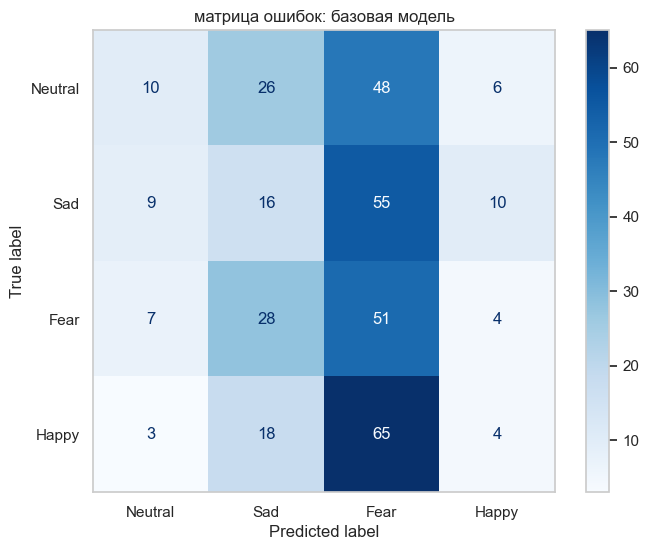


ЗАПУСК: базовая модель-2 на чистых данных с Dropout
Train shape: (360, 128, 128, 4), Test shape: (360, 128, 128, 4)
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 589ms/step - accuracy: 0.2278 - loss: 2.0463 - val_accuracy: 0.2417 - val_loss: 1.3903 - learning_rate: 5.0000e-04
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 534ms/step - accuracy: 0.2667 - loss: 1.3871 - val_accuracy: 0.2778 - val_loss: 1.3883 - learning_rate: 5.0000e-04
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 526ms/step - accuracy: 0.2778 - loss: 1.3818 - val_accuracy: 0.2778 - val_loss: 1.3887 - learning_rate: 5.0000e-04
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 538ms/step - accuracy: 0.3167 - loss: 1.3760 - val_accuracy: 0.2278 - val_loss: 1.3918 - learning_rate: 5.0000e-04
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 546ms/step - accuracy: 0.2861 - loss: 1.3862 - val_accuracy: 0.2611 - val_loss: 1.3910 - learning_rate: 5.0000e-04
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 530ms/step - accuracy: 0.2667 - loss: 1.3662 - val_accuracy:

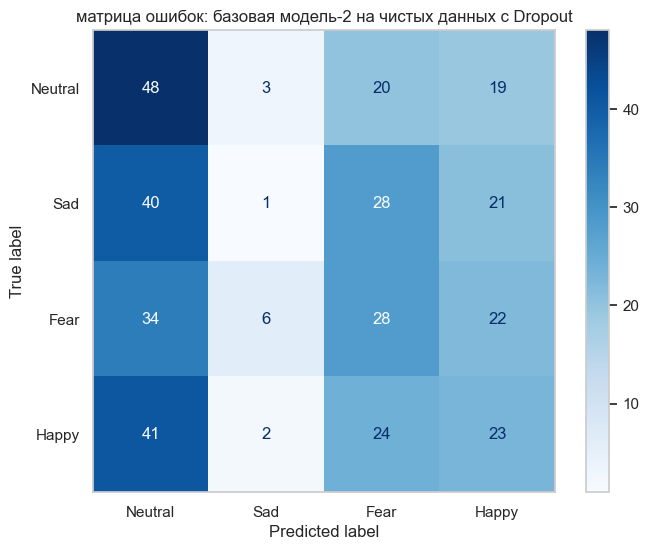


ЗАПУСК: улучшенная модель L2-регуляризация
Train shape: (360, 128, 128, 4), Test shape: (360, 128, 128, 4)
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 938ms/step - accuracy: 0.2528 - loss: 2.8920 - val_accuracy: 0.2444 - val_loss: 1.7710 - learning_rate: 5.0000e-04
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 797ms/step - accuracy: 0.2861 - loss: 1.7651 - val_accuracy: 0.2306 - val_loss: 1.7614 - learning_rate: 5.0000e-04
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 796ms/step - accuracy: 0.3333 - loss: 1.7478 - val_accuracy: 0.2444 - val_loss: 1.7512 - learning_rate: 5.0000e-04
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 795ms/step - accuracy: 0.2972 - loss: 1.7399 - val_accuracy: 0.2139 - val_loss: 1.7406 - learning_rate: 5.0000e-04
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 792ms/step - accuracy: 0.3194 - loss: 1.7232 - val_accuracy: 0.2250 - val_loss: 1.7308 - learning_rate: 5.0000e-04
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 794ms/step - accuracy: 0.3278 - loss: 1.7075 - val_accuracy: 0.23

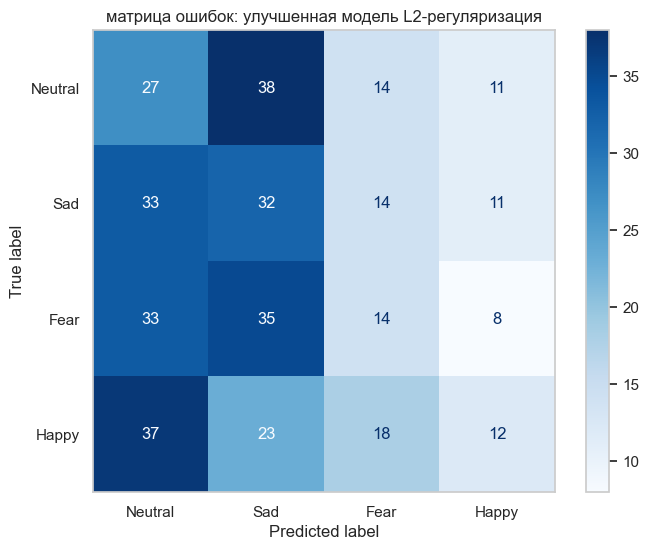


ЗАПУСК: улучшенная модель (2 блока, L2)
Train shape: (360, 128, 128, 4), Test shape: (360, 128, 128, 4)
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 679ms/step - accuracy: 0.2833 - loss: 3.0587 - val_accuracy: 0.2639 - val_loss: 1.5803 - learning_rate: 5.0000e-04
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 558ms/step - accuracy: 0.2306 - loss: 1.5744 - val_accuracy: 0.2528 - val_loss: 1.5627 - learning_rate: 5.0000e-04
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 562ms/step - accuracy: 0.2722 - loss: 1.5563 - val_accuracy: 0.2917 - val_loss: 1.5581 - learning_rate: 5.0000e-04
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 555ms/step - accuracy: 0.2861 - loss: 1.5453 - val_accuracy: 0.2778 - val_loss: 1.5540 - learning_rate: 5.0000e-04
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 550ms/step - accuracy: 0.2778 - loss: 1.5401 - val_accuracy: 0.2667 - val_loss: 1.5492 - learning_rate: 5.0000e-04
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 572ms/step - accuracy: 0.2889 - loss: 1.5193 - val_accuracy: 0.2667 - val

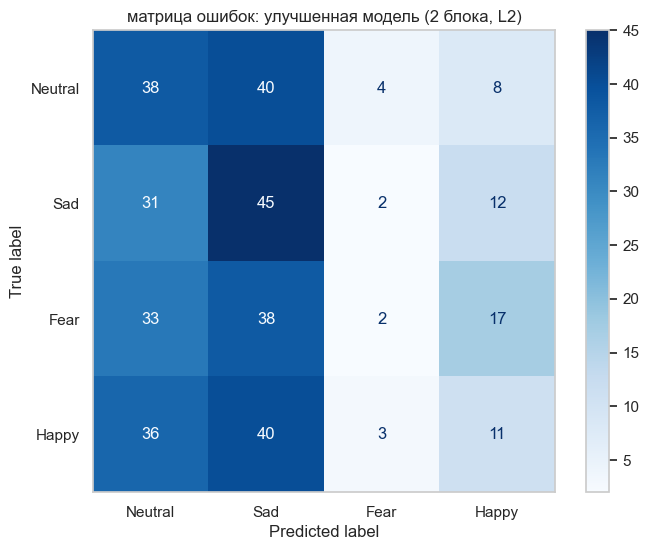


ЗАПУСК: пространственно-временная модель (EEGNet)
Train shape: (360, 60, 10, 5), Test shape: (360, 60, 10, 5)
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.2361 - loss: 1.8126 - val_accuracy: 0.2806 - val_loss: 1.3866 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2444 - loss: 1.5734 - val_accuracy: 0.2750 - val_loss: 1.3840 - learning_rate: 0.0010
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2806 - loss: 1.5420 - val_accuracy: 0.3139 - val_loss: 1.3824 - learning_rate: 0.0010
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.3111 - loss: 1.4448 - val_accuracy: 0.3000 - val_loss: 1.3804 - learning_rate: 0.0010
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.2861 - loss: 1.4349 - val_accuracy: 0.3194 - val_loss: 1.3788 - learning_rate: 0.0010
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3028 - loss: 1.3906 - val_accuracy: 0.3028 - val_loss: 1.3804 - learn

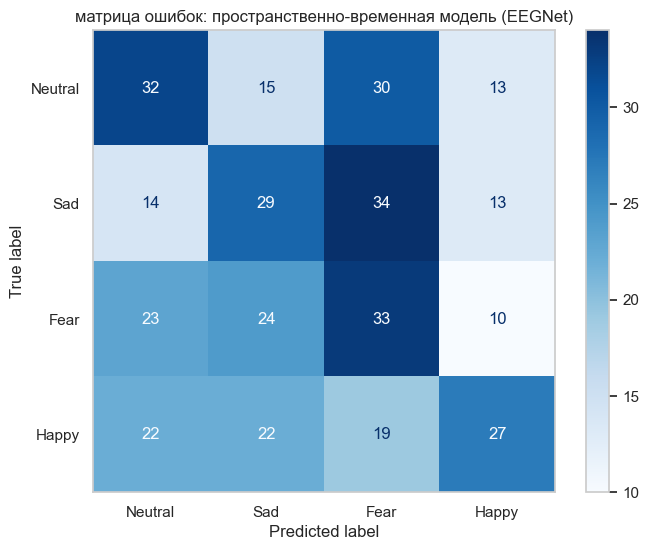


ЗАПУСК: временная модель (TimeDistributed)
Train shape: (360, 10, 32, 32, 1), Test shape: (360, 10, 32, 32, 1)
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 950ms/step - accuracy: 0.2639 - loss: 1.7585 - val_accuracy: 0.2500 - val_loss: 1.5018 - learning_rate: 5.0000e-04
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 767ms/step - accuracy: 0.2306 - loss: 1.6181 - val_accuracy: 0.2639 - val_loss: 1.4921 - learning_rate: 5.0000e-04
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 758ms/step - accuracy: 0.2583 - loss: 1.5360 - val_accuracy: 0.2556 - val_loss: 1.4907 - learning_rate: 5.0000e-04
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 799ms/step - accuracy: 0.2583 - loss: 1.5212 - val_accuracy: 0.2361 - val_loss: 1.4905 - learning_rate: 5.0000e-04
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 791ms/step - accuracy: 0.2306 - loss: 1.5099 - val_accuracy: 0.2722 - val_loss: 1.4882 - learning_rate: 5.0000e-04
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 750ms/step - accuracy: 0.2583 - loss: 1.4949 - val_accuracy: 0

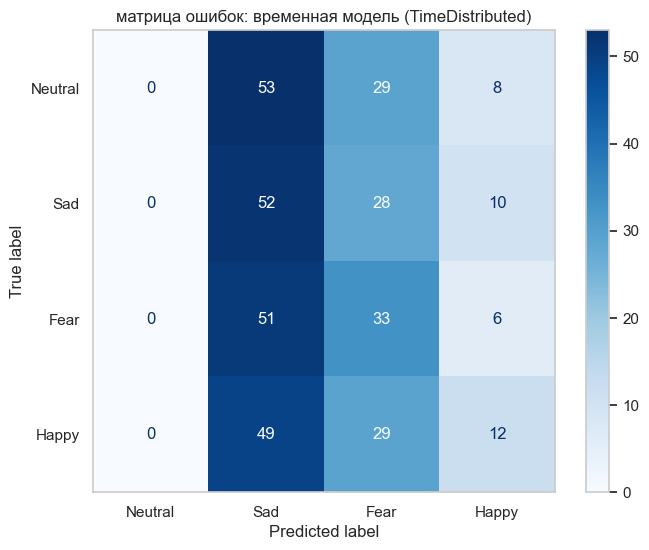


ЗАПУСК: временная модель анализа айтрекинга
Train shape: (360, 10, 31), Test shape: (360, 10, 31)
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.2889 - loss: 1.7404 - val_accuracy: 0.3250 - val_loss: 1.4748 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3944 - loss: 1.4453 - val_accuracy: 0.4056 - val_loss: 1.4451 - learning_rate: 0.0010
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4194 - loss: 1.3702 - val_accuracy: 0.4278 - val_loss: 1.4225 - learning_rate: 0.0010
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4333 - loss: 1.2999 - val_accuracy: 0.4639 - val_loss: 1.3928 - learning_rate: 0.0010
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4917 - loss: 1.2249 - val_accuracy: 0.5028 - val_loss: 1.3656 - learning_rate: 0.0010
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5333 - loss: 1.1498 - val_accuracy: 0.4806 - val_loss: 1.3474 - learning_rate: 0.

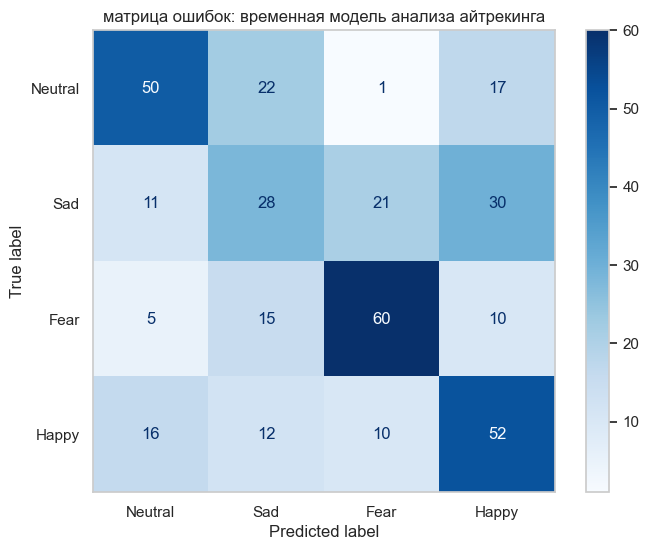

In [26]:
all_results = []

# 1. базовая модель
res1 = run_experiment("базовая модель", X_train_topo, X_test_topo, y_train_topo, y_test_topo, build_base_1)
all_results.append(res1)

# 2. базовая модель-2
res2 = run_experiment("базовая модель-2 на чистых данных с Dropout", X_train_topo, X_test_topo, y_train_topo, y_test_topo, build_base_2)
all_results.append(res2)

# 3. улучшенная модель (L2)
res3 = run_experiment("улучшенная модель L2-регуляризация", X_train_topo, X_test_topo, y_train_topo, y_test_topo, build_improved_l2)
all_results.append(res3)

# 4. улучшенная модель (2 блока, L2)
res4 = run_experiment("улучшенная модель (2 блока, L2)", X_train_topo, X_test_topo, y_train_topo, y_test_topo, build_final_stable)
all_results.append(res4)

# 5. пространственно-временная модель (EEGNet)
res5 = run_experiment("пространственно-временная модель (EEGNet)", X_train_sig, X_test_sig, y_train_sig, y_test_sig, build_spatiotemporal)
all_results.append(res5)

# 6. временная модель (TimeDistributed)
res6 = run_experiment("временная модель (TimeDistributed)", X_train_seq, X_test_seq, y_train_seq, y_test_seq, build_temporal)
all_results.append(res6)

# 7. временная модель анализа айтрекинга (1D-CNN)
res7 = run_experiment("временная модель анализа айтрекинга", X_train_eye_seq, X_test_eye_seq, y_train_eye_seq, y_test_eye_seq, build_temporal_eye_1dcnn)
all_results.append(res7)

Форма предсказаний: (2, 4)
Форма признаков: (2, 128)
Lambda MMD: 0.1
Patience: 10 эпох
Максимальное количество эпох: 100

Epoch 001 | Val Acc: 0.2500 (NEW BEST!) | CCE: 2.0894 | MMD: 0.0692
Epoch 002 | Val Acc: 0.2500 | Best: 0.2500 | Patience: 1/10
Epoch 003 | Val Acc: 0.2583 (NEW BEST!) | CCE: 1.3893 | MMD: 0.0500
Epoch 004 | Val Acc: 0.2583 | Best: 0.2583 | Patience: 1/10
Epoch 005 | Val Acc: 0.2694 (NEW BEST!) | CCE: 1.3838 | MMD: 0.0066
Epoch 006 | Val Acc: 0.2611 | Best: 0.2694 | Patience: 1/10
Epoch 007 | Val Acc: 0.2583 | Best: 0.2694 | Patience: 2/10
Epoch 008 | Val Acc: 0.2556 | Best: 0.2694 | Patience: 3/10
Epoch 009 | Val Acc: 0.2667 | Best: 0.2694 | Patience: 4/10
Epoch 010 | Val Acc: 0.2611 | Best: 0.2694 | Patience: 5/10
Epoch 011 | Val Acc: 0.2667 | Best: 0.2694 | Patience: 6/10
Epoch 012 | Val Acc: 0.2611 | Best: 0.2694 | Patience: 7/10
Epoch 013 | Val Acc: 0.2694 | Best: 0.2694 | Patience: 8/10
Epoch 014 | Val Acc: 0.2583 | Best: 0.2694 | Patience: 9/10
Epoch 015 | Va

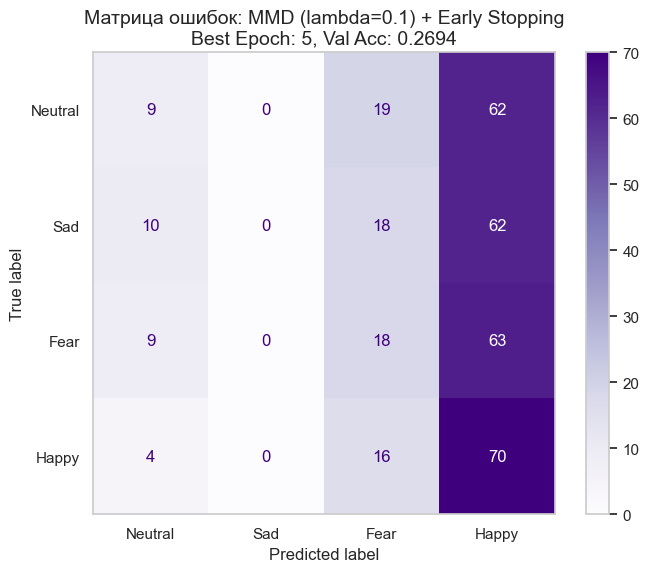

In [27]:
# 8. модель MMD Domain Adoptation
def gaussian_rbf_kernel(x, y, sigma=1.0):
    x_norm = tf.reduce_sum(tf.square(x), axis=1)
    y_norm = tf.reduce_sum(tf.square(y), axis=1)
    xy = tf.matmul(x, tf.transpose(y))
    return tf.exp(-(x_norm[:, tf.newaxis] + y_norm[tf.newaxis, :] - 2 * xy) / (2 * tf.square(sigma)))

def mmd_loss(source_features, target_features):
    xx = gaussian_rbf_kernel(source_features, source_features)
    yy = gaussian_rbf_kernel(target_features, target_features)
    xy = gaussian_rbf_kernel(source_features, target_features)
    return tf.reduce_mean(xx) + tf.reduce_mean(yy) - 2 * tf.reduce_mean(xy)

class DomainAdaptationCNN(tf.keras.Model):
    def __init__(self, num_classes):
        super(DomainAdaptationCNN, self).__init__()
        self.conv1 = layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001))
        self.pool1 = layers.MaxPooling2D((2, 2))
        self.drop1 = layers.Dropout(0.2)
        self.conv2 = layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001))
        self.pool2 = layers.MaxPooling2D((2, 2))
        self.drop2 = layers.Dropout(0.3)
        self.flatten = layers.Flatten()
        self.dense_feat = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))
        self.drop_feat = layers.Dropout(0.4)
        self.classifier = layers.Dense(num_classes, activation='softmax')

    def call(self, inputs, training=False):
        x = self.conv1(inputs)
        x = self.pool1(x)
        x = self.drop1(x, training=training)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.drop2(x, training=training)
        x = self.flatten(x)
        features = self.dense_feat(x)
        features = self.drop_feat(features, training=training)
        predictions = self.classifier(features)
        return predictions, features

da_model = DomainAdaptationCNN(num_classes=4)
dummy_pred, dummy_feat = da_model(X_train_mmd[:2], training=False)
print(f"Форма предсказаний: {dummy_pred.shape}")
print(f"Форма признаков: {dummy_feat.shape}")

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
loss_fn = tf.keras.losses.CategoricalCrossentropy()
lambda_mmd = 0.1
patience = 10
min_delta = 0.001
epochs_max = 100
batch_size = 32
steps_per_epoch = len(X_train_mmd) // batch_size

best_val_accuracy = 0
best_epoch = 0
patience_counter = 0
best_weights = None

history_mmd = {'cce': [], 'mmd': [], 'total_loss': [], 'val_accuracy': []}

y_train_mmd_cat = to_categorical(y_train_mmd, num_classes)
y_test_mmd_cat = to_categorical(y_test_mmd, num_classes)

print(f"Lambda MMD: {lambda_mmd}")
print(f"Patience: {patience} эпох")
print(f"Максимальное количество эпох: {epochs_max}\n")

for epoch in range(epochs_max):
    epoch_cce = 0
    epoch_mmd = 0
    epoch_total = 0
    
    indices = tf.random.shuffle(tf.range(len(X_train_mmd)))
    for step in range(steps_per_epoch):
        start_idx = step * batch_size
        end_idx = start_idx + batch_size
        
        idx_batch = indices[start_idx:end_idx]
        x_source = tf.gather(X_train_mmd, idx_batch)
        y_source = tf.gather(y_train_mmd_cat, idx_batch)
        x_target = X_test_mmd[start_idx:end_idx]
        
        with tf.GradientTape() as tape:
            pred_source, feat_source = da_model(x_source, training=True)
            _, feat_target = da_model(x_target, training=True)
            cce_loss = loss_fn(y_source, pred_source)
            mmd = mmd_loss(feat_source, feat_target)
            total_loss = cce_loss + lambda_mmd * mmd
        
        gradients = tape.gradient(total_loss, da_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, da_model.trainable_variables))
        
        epoch_cce += cce_loss
        epoch_mmd += mmd
        epoch_total += total_loss
    
    history_mmd['cce'].append(epoch_cce / steps_per_epoch)
    history_mmd['mmd'].append(epoch_mmd / steps_per_epoch)
    history_mmd['total_loss'].append(epoch_total / steps_per_epoch)
    
    val_preds, _ = da_model(X_test_mmd, training=False)
    val_acc = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(val_preds, 1), tf.argmax(y_test_mmd_cat, 1)), tf.float32)).numpy()
    history_mmd['val_accuracy'].append(val_acc)
    
    improved = False
    if val_acc > best_val_accuracy + min_delta:
        best_val_accuracy = val_acc
        best_epoch = epoch
        patience_counter = 0
        improved = True
        best_weights = [w.numpy() for w in da_model.trainable_variables]
        print(f"Epoch {epoch+1:03d} | Val Acc: {val_acc:.4f} (NEW BEST!) | "
              f"CCE: {history_mmd['cce'][-1]:.4f} | MMD: {history_mmd['mmd'][-1]:.4f}")
    else:
        patience_counter += 1
        print(f"Epoch {epoch+1:03d} | Val Acc: {val_acc:.4f} | "
              f"Best: {best_val_accuracy:.4f} | Patience: {patience_counter}/{patience}")
    
    if patience_counter >= patience:
        print(f"\nEarly Stopping сработал на эпохе {epoch+1}!")
        print(f"Лучшая точность была на эпохе {best_epoch+1}: {best_val_accuracy:.4f}")
        print(f"Восстанавливаем веса лучшей модели")
        for w, best_w in zip(da_model.trainable_variables, best_weights):
            w.assign(best_w)
        break
    
    if epoch == epochs_max - 1:
        print(f"\nДостигнут лимит эпох ({epochs_max})")
        if best_weights is not None:
            print(f"Восстанавливаем веса лучшей модели (эпоха {best_epoch+1})...")
            for w, best_w in zip(da_model.trainable_variables, best_weights):
                w.assign(best_w)

print("\nОтчёт о классификации (MMD + early stopping)")
final_preds, _ = da_model(X_test_mmd, training=False)
final_preds = tf.argmax(final_preds, 1).numpy()
y_true_final = tf.argmax(y_test_mmd_cat, 1).numpy()

report_mmd = classification_report(y_true_final, final_preds, target_names=class_names, output_dict=True)
print(classification_report(y_true_final, final_preds, target_names=class_names))

cm = confusion_matrix(y_true_final, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Purples', ax=ax, values_format='d')
ax.grid(False)
plt.title(f'Матрица ошибок: MMD (lambda={lambda_mmd}) + Early Stopping\nBest Epoch: {best_epoch+1}, Val Acc: {best_val_accuracy:.4f}', fontsize=14)
plt.show()

results_mmd = {
    "Наименование модели CNN": "MMD Domain Adaptation",
    "Точность (Accuracy)": report_mmd['accuracy'],
    "Прецизионность (Precision, macro)": report_mmd['macro avg']['precision'],
    "Полнота (Recall, macro)": report_mmd['macro avg']['recall'],
    "F1-мера (macro)": report_mmd['macro avg']['f1-score'],
    "F1-мера (weighted)": report_mmd['weighted avg']['f1-score'],
    "Финальные потери на валидации": 0.0,
    "Количество эпох обучения": len(history_mmd['val_accuracy'])
}

all_results.append(results_mmd)

<a id=3.5.></a>
### 3.5. Фиксация результатов обучения унимодальных моделей

In [28]:
# формируем датафрейм с метриками
df_results = pd.DataFrame(all_results)

# задаём форматирование данных (создаём новые столбцы с отформатированными значениями)
df_results['Accuracy'] = df_results['Точность (Accuracy)'].apply(lambda x: f"{x:.2%}")
df_results['F1-Score (macro)'] = df_results['F1-мера (macro)'].apply(lambda x: f"{x:.2%}")
df_results['F1-Score (weighted)'] = df_results['F1-мера (weighted)'].apply(lambda x: f"{x:.2%}")

print("\nСРАВНЕНИЕ УНИМОДАЛЬНЫХ МОДЕЛЕЙ")
# подсвечиваем максимальные значения в новых отформатированных столбцах
styled_df = df_results.style.highlight_max(subset=['Accuracy', 'F1-Score (macro)'], color='lightgreen')
display(styled_df)


СРАВНЕНИЕ УНИМОДАЛЬНЫХ МОДЕЛЕЙ


,Наименование модели CNN,Точность (Accuracy),"Прецизионность (Precision, macro)","Полнота (Recall, macro)",F1-мера (macro),F1-мера (weighted),Финальные потери на валидации,Количество эпох обучения,Accuracy,F1-Score (macro),F1-Score (weighted)
0,базовая модель,0.225000,0.231547,0.225000,0.187029,0.187029,1.899196,12,22.50%,18.70%,18.70%
1,базовая модель-2 на чистых данных с Dropout,0.277778,0.232100,0.277778,0.239162,0.239162,1.409824,12,27.78%,23.92%,23.92%
2,улучшенная модель L2-регуляризация,0.236111,0.244185,0.236111,0.226879,0.226879,1.745313,22,23.61%,22.69%,22.69%
3,"улучшенная модель (2 блока, L2)",0.266667,0.240605,0.266667,0.222022,0.222022,1.577085,16,26.67%,22.20%,22.20%
4,пространственно-временная модель (EEGNet),0.336111,0.346731,0.336111,0.337286,0.337286,1.398332,25,33.61%,33.73%,33.73%
5,временная модель (TimeDistributed),0.269444,0.216076,0.269444,0.214702,0.214702,1.464407,50,26.94%,21.47%,21.47%
6,временная модель анализа айтрекинга,0.527778,0.525658,0.527778,0.524670,0.524670,1.267678,30,52.78%,52.47%,52.47%
7,MMD Domain Adaptation,0.269444,0.201786,0.269444,0.193650,0.193650,0.000000,15,26.94%,19.37%,19.37%


<a id=4></a>
## Шаг 4. Мультимодальные модели (ЭЭГ + айтрекинг)

<a id=4.1.></a>
### 4.1. Подготовка данных для мультимодальных моделей

Собираем топокарты для первой мультимодальной модели и сырые сигналы для второй пространственно-временной модели. Данные айтрекинга для обеих моделей одинаковые.

In [29]:
# подготовка данных для мультимодальных моделей
# сбор сырых данных (ЭЭГ + айтрекинг)
X_eeg_raw_list, X_eye_list, y_list, sessions_list = [], [], [], []

for subj, data in RAW_DATA.items():
    for sess in [1, 2]:
        for t in range(1, 25):
            key_eeg = f"de_LDS{t}"  # ЭЭГ
            key_eye = f"eye_{t}"    # айтрекинг
            
            if key_eeg in data['sessions'][sess]['eeg'] and key_eye in data['sessions'][sess]['eye']:
                eeg = data['sessions'][sess]['eeg'][key_eeg]
                eeg_trimmed = eeg[:, :real_windows, :]
                eeg_clean = np.delete(eeg_trimmed, EXCLUDE_INDICES, axis=0) # (60, W, 5)
                
                X_eeg_raw_list.append(eeg_clean)
                X_eye_list.append(data['sessions'][sess]['eye'][key_eye])
                y_list.append(SEED_IV_LABELS[sess][t-1])
                sessions_list.append(sess)

X_eeg_raw = np.array(X_eeg_raw_list, dtype='float32')
X_eye = np.array(X_eye_list, dtype='float32')
y_multi = np.array(y_list)
sessions_multi = np.array(sessions_list)

print(f"Собрано примеров: {len(y_multi)}")
print(f"Форма сырых ЭЭГ: {X_eeg_raw.shape}")
print(f"Форма айтрекинга: {X_eye.shape}")

# генерация топокарт для мультимодальной модели (топокарты + айтрекинг)
X_eeg_topo_list = []
for eeg in X_eeg_raw:
    # медиана по времени, усреднение по частотам
    vals = np.mean(np.median(eeg, axis=1), axis=1)
    img = generate_topomap_fast(vals, COORDS_2D, img_size=128)
    img = np.expand_dims(img, axis=-1) # (128, 128, 1)
    X_eeg_topo_list.append(img)
    
X_eeg_topo = np.array(X_eeg_topo_list, dtype='float32') / 255.0
print(f"Форма топокарт ЭЭГ: {X_eeg_topo.shape}")

# разделение на сессии
mask_train = (sessions_multi == 1)
mask_test = (sessions_multi == 2)

# нормализация айтрекинга (Z-score по train)
eye_mean = X_eye[mask_train].mean(axis=0)
eye_std = X_eye[mask_train].std(axis=0) + 1e-8
X_eye_norm = (X_eye - eye_mean) / eye_std

X_eye_train = X_eye_norm[mask_train]
X_eye_test = X_eye_norm[mask_test]

# нормализация сырых ЭЭГ (Z-score по train)
eeg_raw_mean = X_eeg_raw[mask_train].mean(axis=0, keepdims=True)
eeg_raw_std = X_eeg_raw[mask_train].std(axis=0, keepdims=True) + 1e-8
X_eeg_raw_norm = (X_eeg_raw - eeg_raw_mean) / eeg_raw_std

X_eeg_raw_train = X_eeg_raw_norm[mask_train]
X_eeg_raw_test = X_eeg_raw_norm[mask_test]

# нормализация топокарт (baseline subtraction + Z-score)
neutral_idx = np.where((y_multi == 0) & mask_train)[0]
topo_baseline = np.mean(X_eeg_topo[neutral_idx], axis=0)
X_eeg_topo_bl = X_eeg_topo - topo_baseline
X_eeg_topo_norm = (X_eeg_topo_bl - X_eeg_topo_bl.mean()) / (X_eeg_topo_bl.std() + 1e-8)

X_eeg_topo_train = X_eeg_topo_norm[mask_train]
X_eeg_topo_test = X_eeg_topo_norm[mask_test]

# общие метки
y_train_multi = y_multi[mask_train]
y_test_multi = y_multi[mask_test]

print("\nДанные для мультимодальных моделей:")
print(f"EEG Topo Train: {X_eeg_topo_train.shape}, Test: {X_eeg_topo_test.shape}")
print(f"EEG Raw Train:  {X_eeg_raw_train.shape}, Test: {X_eeg_raw_test.shape}")
print(f"Eye Train:      {X_eye_train.shape}, Test: {X_eye_test.shape}")

Собрано примеров: 720
Форма сырых ЭЭГ: (720, 60, 10, 5)
Форма айтрекинга: (720, 31)
Форма топокарт ЭЭГ: (720, 128, 128, 1)

Данные для мультимодальных моделей:
EEG Topo Train: (360, 128, 128, 1), Test: (360, 128, 128, 1)
EEG Raw Train:  (360, 60, 10, 5), Test: (360, 60, 10, 5)
Eye Train:      (360, 31), Test: (360, 31)


<a id=4.2.></a>
### 4.2. Архитектуры мультимодальных моделей CNN

In [30]:
# 1. мультимодальная модель: топокарты (CNN) + айтрекинг (Dense)
def build_multimodal_topo_eye(eeg_input_shape, eye_input_shape):
    # ветвь 1: ЭЭГ (топокарты)
    eeg_input = layers.Input(shape=eeg_input_shape)
    x1 = layers.Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001))(eeg_input)
    x1 = layers.MaxPooling2D((2, 2))(x1)
    x1 = layers.Dropout(0.2)(x1)
    x1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.001))(x1)
    x1 = layers.MaxPooling2D((2, 2))(x1)
    x1 = layers.Dropout(0.3)(x1)
    x1 = layers.Flatten()(x1)
    x1 = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x1)
    x1 = layers.Dropout(0.4)(x1)
    
    # ветвь 2: айтрекинг
    eye_input = layers.Input(shape=eye_input_shape)
    x2 = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(eye_input)
    x2 = layers.Dropout(0.3)(x2)
    x2 = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x2)
    x2 = layers.Dropout(0.3)(x2)
    
    # fusion и классификатор
    merged = layers.Concatenate()([x1, x2])
    out = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(merged)
    out = layers.Dropout(0.5)(out)
    out = layers.Dense(num_classes, activation='softmax')(out)
    
    model = tf.keras.Model(inputs=[eeg_input, eye_input], outputs=out)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 2. мультимодальная пространственно-временная модель: сырые сигналы ЭЭГ + айтрекинг
def build_multimodal_spatiotemporal_eye(eeg_input_shape, eye_input_shape):
    # ветвь 1: ЭЭГ (пространственно-временная)
    eeg_input = layers.Input(shape=eeg_input_shape)
    x1 = layers.Conv2D(16, kernel_size=(1, 5), padding='same')(eeg_input)
    x1 = layers.BatchNormalization()(x1); x1 = layers.Activation('relu')(x1)
    x1 = layers.DepthwiseConv2D((60, 1), depth_multiplier=2, use_bias=False)(x1)
    x1 = layers.BatchNormalization()(x1); x1 = layers.Activation('relu')(x1)
    x1 = layers.MaxPooling2D((1, 2))(x1); x1 = layers.Dropout(0.4)(x1)
    x1 = layers.Flatten()(x1)
    x1 = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x1)
    x1 = layers.Dropout(0.3)(x1)
    
    # ветвь 2: айтрекинг
    eye_input = layers.Input(shape=eye_input_shape)
    x2 = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(eye_input)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Dropout(0.3)(x2)
    x2 = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x2)
    x2 = layers.Dropout(0.3)(x2)
    
    # fusion и классификатор
    merged = layers.Concatenate()([x1, x2])
    out = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(merged)
    out = layers.BatchNormalization()(out)
    out = layers.Dropout(0.5)(out)
    out = layers.Dense(num_classes, activation='softmax')(out)
    
    model = tf.keras.Model(inputs=[eeg_input, eye_input], outputs=out)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

<a id=4.3.></a>
### 4.3. Функция запуска для мультимодальных моделей
Дорабатываем функцию из шага 3, чтобы она принимала две ветви данных и возвращала тот же словарь с ключами метрик.

In [31]:
def run_multimodal_experiment(model_name, X_eeg_train, X_eeg_test, X_eye_train, X_eye_test, y_train, y_test, model_builder_func):
    """Универсальный пайплайн для мультимодальных моделей."""
    # one-hot encoding
    y_train_cat = to_categorical(y_train, num_classes)
    y_test_cat = to_categorical(y_test, num_classes)
    
    # сборка модели
    model = model_builder_func(X_eeg_train.shape[1:], X_eye_train.shape[1:])
    
    # callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5, verbose=1)
    ]
    
    # обучение
    history = model.fit([X_eeg_train, X_eye_train], y_train_cat, validation_data=([X_eeg_test, X_eye_test], y_test_cat), epochs=100, batch_size=32, callbacks=callbacks, verbose=1)
    
    # оценка
    y_pred_probs = model.predict([X_eeg_test, X_eye_test], verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)
    
    # отчёт о классификации
    print(f"\nОТЧЁТ О КЛАССИФИКАЦИИ: {model_name}")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Reds', ax=ax, values_format='d')
    plt.title(f'Матрица ошибок: {model_name}')
    ax.grid(False)
    plt.show()
    
    # сбор метрик
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    results = {
        "Наименование модели CNN": model_name,
        "Точность (Accuracy)": report_dict['accuracy'],
        "Прецизионность (Precision, macro)": report_dict['macro avg']['precision'],
        "Полнота (Recall, macro)": report_dict['macro avg']['recall'],
        "F1-мера (macro)": report_dict['macro avg']['f1-score'],
        "F1-мера (weighted)": report_dict['weighted avg']['f1-score'],
        "Финальные потери на валидации": history.history['val_loss'][-1],
        "Количество эпох обучения": len(history.history['loss'])
    }
    return results

<a id=4.4.></a>
### 4.4. Обучение мультимодальных моделей

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 608ms/step - accuracy: 0.2250 - loss: 2.0154 - val_accuracy: 0.2667 - val_loss: 1.7242 - learning_rate: 5.0000e-04
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 560ms/step - accuracy: 0.2556 - loss: 1.7860 - val_accuracy: 0.3222 - val_loss: 1.6968 - learning_rate: 5.0000e-04
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 516ms/step - accuracy: 0.2972 - loss: 1.7326 - val_accuracy: 0.3417 - val_loss: 1.6717 - learning_rate: 5.0000e-04
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 505ms/step - accuracy: 0.2556 - loss: 1.6932 - val_accuracy: 0.3778 - val_loss: 1.6492 - learning_rate: 5.0000e-04
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 508ms/step - accuracy: 0.3361 - loss: 1.6642 - val_accuracy: 0.3917 - val_loss: 1.6292 - learning_rate: 5.0000e-04
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 516ms/step - accuracy: 0.3139 - loss: 1.6221 - val_accuracy: 0.4278 - val_loss: 1.6101 - learning_rate: 5.0000e-04
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 510ms/step - a

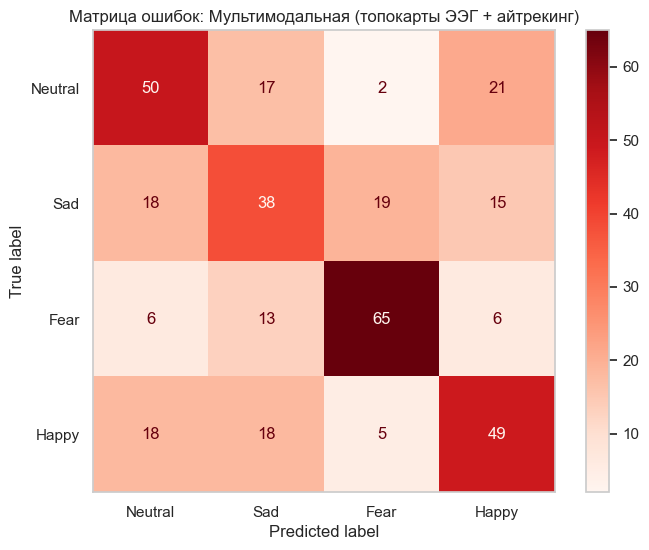

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.2806 - loss: 2.5169 - val_accuracy: 0.2806 - val_loss: 1.6711 - learning_rate: 5.0000e-04
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2806 - loss: 2.3319 - val_accuracy: 0.3306 - val_loss: 1.6525 - learning_rate: 5.0000e-04
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3139 - loss: 2.3662 - val_accuracy: 0.3194 - val_loss: 1.6409 - learning_rate: 5.0000e-04
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2861 - loss: 2.2332 - val_accuracy: 0.3361 - val_loss: 1.6312 - learning_rate: 5.0000e-04
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.3000 - loss: 2.1634 - val_accuracy: 0.3556 - val_loss: 1.6204 - learning_rate: 5.0000e-04
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3139 - loss: 2.2229 - val_accuracy: 0.3556 - val_loss: 1.6109 - learning_rate: 5.0000e-04
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy

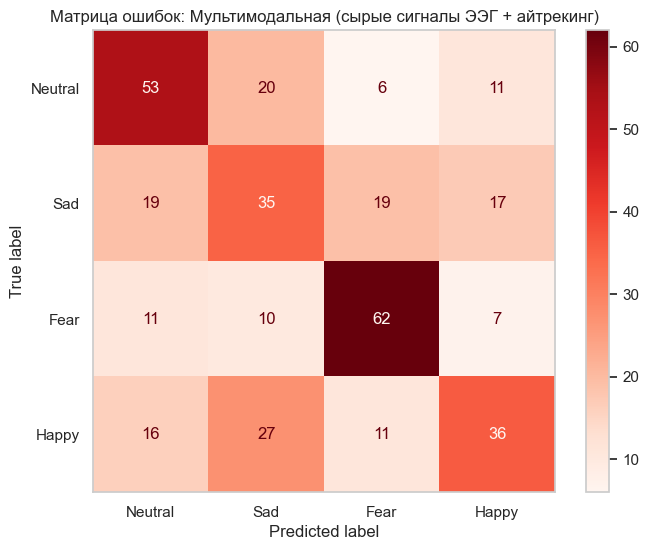

In [32]:
# 1. мультимодальная модель на топокартах + айтрекинг
res_multi_1 = run_multimodal_experiment("Мультимодальная (топокарты ЭЭГ + айтрекинг)", X_eeg_topo_train, X_eeg_topo_test, X_eye_train, X_eye_test, y_train_multi, y_test_multi, build_multimodal_topo_eye)
all_results.append(res_multi_1)

# 2. мультимодальная пространственно-временная модель на сырых сигналах ЭЭГ + айтрекинг
res_multi_2 = run_multimodal_experiment("Мультимодальная (сырые сигналы ЭЭГ + айтрекинг)", X_eeg_raw_train, X_eeg_raw_test, X_eye_train, X_eye_test, y_train_multi, y_test_multi, build_multimodal_spatiotemporal_eye)
all_results.append(res_multi_2)

<a id=4.5.></a>
### 4.5. Фиксация результатов и итоговое сравнение

In [33]:
# формируем итоговый DataFrame
df_results = pd.DataFrame(all_results)

# форматирование для наглядности полученных результатов
df_results['Accuracy'] = df_results['Точность (Accuracy)'].apply(lambda x: f"{x:.2%}")
df_results['F1-Score (macro)'] = df_results['F1-мера (macro)'].apply(lambda x: f"{x:.2%}")
df_results['F1-Score (weighted)'] = df_results['F1-мера (weighted)'].apply(lambda x: f"{x:.2%}")

print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ТИПОВ МОДЕЛЕЙ (УНИМОДАЛЬНЫЕ + МУЛЬТИМОДАЛЬНЫЕ)")

styled_df = df_results.style.highlight_max(subset=['Accuracy', 'F1-Score (macro)'], color='lightgreen')
display(styled_df)

ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ТИПОВ МОДЕЛЕЙ (УНИМОДАЛЬНЫЕ + МУЛЬТИМОДАЛЬНЫЕ)


,Наименование модели CNN,Точность (Accuracy),"Прецизионность (Precision, macro)","Полнота (Recall, macro)",F1-мера (macro),F1-мера (weighted),Финальные потери на валидации,Количество эпох обучения,Accuracy,F1-Score (macro),F1-Score (weighted)
0,базовая модель,0.225000,0.231547,0.225000,0.187029,0.187029,1.899196,12,22.50%,18.70%,18.70%
1,базовая модель-2 на чистых данных с Dropout,0.277778,0.232100,0.277778,0.239162,0.239162,1.409824,12,27.78%,23.92%,23.92%
2,улучшенная модель L2-регуляризация,0.236111,0.244185,0.236111,0.226879,0.226879,1.745313,22,23.61%,22.69%,22.69%
3,"улучшенная модель (2 блока, L2)",0.266667,0.240605,0.266667,0.222022,0.222022,1.577085,16,26.67%,22.20%,22.20%
4,пространственно-временная модель (EEGNet),0.336111,0.346731,0.336111,0.337286,0.337286,1.398332,25,33.61%,33.73%,33.73%
5,временная модель (TimeDistributed),0.269444,0.216076,0.269444,0.214702,0.214702,1.464407,50,26.94%,21.47%,21.47%
6,временная модель анализа айтрекинга,0.527778,0.525658,0.527778,0.524670,0.524670,1.267678,30,52.78%,52.47%,52.47%
7,MMD Domain Adaptation,0.269444,0.201786,0.269444,0.193650,0.193650,0.000000,15,26.94%,19.37%,19.37%
8,Мультимодальная (топокарты ЭЭГ + айтрекинг),0.561111,0.559521,0.561111,0.560234,0.560234,1.199554,100,56.11%,56.02%,56.02%
9,Мультимодальная (сырые сигналы ЭЭГ + айтрекинг),0.516667,0.513871,0.516667,0.513060,0.513060,1.401914,57,51.67%,51.31%,51.31%


In [34]:
# сравнительный анализ: влияние мультимодальности на полученные результаты
# находим лучшую унимодальную модель (первые 8 строк)
df_unimodal = df_results.iloc[:-2] 
best_uni_idx = df_unimodal['Точность (Accuracy)'].idxmax()
best_unimodal = df_results.loc[best_uni_idx]

# находим лучшую мультимодальную модель (последние 2 строки)
df_multimodal = df_results.iloc[-2:]
best_multi_idx = df_multimodal['Точность (Accuracy)'].idxmax()
best_multimodal = df_results.loc[best_multi_idx]

print(f"\nЛучшая унимодальная модель: {best_unimodal['Наименование модели CNN']}")
print(f"   Accuracy: {best_unimodal['Accuracy']} | F1-macro: {best_unimodal['F1-Score (macro)']}")

print(f"\nЛучшая мультимодальная модель: {best_multimodal['Наименование модели CNN']}")
print(f"   Accuracy: {best_multimodal['Accuracy']} | F1-macro: {best_multimodal['F1-Score (macro)']}")


Лучшая унимодальная модель: временная модель анализа айтрекинга
   Accuracy: 52.78% | F1-macro: 52.47%

Лучшая мультимодальная модель: Мультимодальная (топокарты ЭЭГ + айтрекинг)
   Accuracy: 56.11% | F1-macro: 56.02%


In [35]:
# вычисляем прирост точности
acc_uni = float(best_unimodal['Accuracy'].replace('%', ''))
acc_multi = float(best_multimodal['Accuracy'].replace('%', ''))
improvement = acc_multi - acc_uni

print(f"\nПрирост точности: {improvement:+.2f}%")


Прирост точности: +3.33%


Анализ итоговой сравнительной таблицы метрик позволяет сделать глубокие выводы о специфике распознавания эмоций, качестве извлеченных признаков и эффективности различных архитектур нейронных сетей. Задача классификации четырех эмоциональных состояний (нейтральность, грусть, страх, радость) объективно является сложной, поскольку базовый уровень случайного угадывания (baseline) составляет 25%. Результаты экспериментов наглядно демонстрируют, что не все модальности и способы их представления вносят равнозначный вклад в итоговое качество модели.

Анализ унимодальных моделей на основе ЭЭГ выявляет фундаментальную проблему работы с топографическими картами мозга в условиях высокого уровня шума и межсубъектной вариативности. Базовые модели (№1 и №2) и модели с L2-регуляризацией (№3 и №4) показали результаты, колеблющиеся в районе 22.5–27.8%, что фактически соответствует уровню случайного угадывания или предсказания мажоритарного класса (о чем свидетельствует низкая F1-мера macro, особенно у модели №2, которая «сломалась» и коллапсировала в предсказание одного класса). Единственной архитектурой, которой удалось существенно преодолеть этот барьер, стала пространственно-временная модель EEGNet (№5), достигшая точности 33.61% и F1-macro 33.73%. Этот успех подтверждает, что для сырых сигналов ЭЭГ критически важно сохранять их нативную временную и частотную структуру, а не полагаться на интерполированные 2D-топокарты, которые теряют часть динамики и подвержены артефактам. Временная модель TimeDistributed (№6) также не показала эффективности (26.94%), вероятно, из-за потери пространственной детализации при агрессивном пулинге.

Сравнение модальностей показывает парадоксальный, но физиологически обоснованный результат: унимодальная модель на основе айтрекинга (№7) значительно превзошла все модели на основе ЭЭГ, достигнув точности 52.78% и F1-macro 52.47%. Это свидетельствует о том, что вегетативные реакции периферической нервной системы (диаметр зрачка, частота морганий, паттерны саккад) в рамках данного датасета оказались более стабильными, информативными и легкими для извлечения сверточными сетями (1D-CNN), чем когнитивные паттерны центральной нервной системы, зашумленные индивидуальными особенностями коры. Модель доменной адаптации MMD (№8) показала умеренный результат (26.94%), что подчеркивает сложность задачи выравнивания распределений (Domain Shift) между сессиями без использования дополнительных методов аугментации или переноса знаний.

Переход к мультимодальным архитектурам доказывает гипотезу о синергии центральных и периферических физиологических маркеров. Лучшим результатом всего исследования обладает мультимодальная модель на основе топокарт ЭЭГ и айтрекинга (№9) с точностью 56.11% и F1-macro 56.02%. Механизм Late Fusion позволил сети скомбинировать пространственные паттерны мозга (пусть и зашумленные) с высокоточными вегетативными маркерами глаз, что дало прирост в +3.33% к абсолютной точности по сравнению с лучшей унимодальной моделью. При этом мультимодальная модель на сырых сигналах ЭЭГ (№10) показала результат ниже (51.67%). Это важное архитектурное наблюдение: агрегация сырого сигнала ЭЭГ в медианные топокарты перед подачей в CNN сработала как эффективный фильтр низких частот, отсекший высокочастотный шум, который в случае с сырым сигналом (модель №10) помешал эффективному слиянию с признаками айтрекинга.

Таким образом, итоговое сравнение подводит к следующему заключению: задача распознавания эмоций не может быть решена исключительно «в лоб» на сырых пространственно-временных данных ЭЭГ из-за их экстремальной зашумленности. Наибольшую дискриминативную силу в данном эксперименте продемонстрировали вегетативные маркеры (айтрекинг). Однако именно мультимодальный фреймворк, объединяющий сглаженные пространственные паттерны мозга (топокарты) и динамические реакции глаз, позволил создать наиболее робастную систему, способную компенсировать слабые места каждой из модальностей за счет взаимного дополнения информации на уровне латентных признаков.

<a id=5></a>
## Вывод

Подведение итогов данного исследования требует осмысления не только полученных метрик, но и фундаментальных особенностей работы с нейрофизиологическими данными. Главным выводом работы стало понимание того, что перенос методов глубокого обучения из классического компьютерного зрения в область нейронаук требует колоссальной адаптации и строгого уважения к доменной области. Подготовка данных здесь выходит на первый план: нормализация данных является не опцией, а строгим требованием для стабильной работы градиентного спуска в CNN. Аугментация данных для топокарт ЭЭГ недопустима, поскольку ключевым биомаркером при распознавании эмоций (и многих психических состояний) является именно межполушарная асимметрия (например, фронтальная альфа-асимметрия: большая активность левого полушария ассоциируется с подходом/радостью, а правого – с избеганием/тревогой). Горизонтальное отражение топокарты поменяет местами электроды F3 и F4, P7 и P8, полностью инвертировав физиологический смысл сигнала и создав анатомический нонсенс. Для данных ЭЭГ допустима только строгая аугментация, сохраняющая пространственную привязку (например, добавление гауссовского шума к каналам, временные сдвиги или маскирование каналов), но никак не геометрические трансформации изображения. Попытка применить агрессивные методы аугментации, стандартные для изображений, в медицине и нейрофизиологии не просто снижает качество модели — она генерирует неанатомические артефакты, полностью разрушая физиологический смысл сигнала.

Эволюция архитектур моделей наглядно демонстрирует, как постепенное усложнение и адаптация под природу сигналов приводит к уверенному росту качества классификации. Базовые модели, обрабатывающие топокарты как обычные картинки, застряли на уровне случайного угадывания (~25%), не сумев преодолеть высокий уровень шума и межсубъектной вариативности. Первый осознанный скачок точности до 33.6% произошел благодаря внедрению пространственно-временной архитектуры EEGNet, которая отказалась от интерполированных картинок в пользу сырых сигналов, начав извлекать паттерны напрямую, сохраняя нативную временную и частотную структуру. Однако настоящий прорыв случился при переходе к мультимодальности. Добавление вегетативных маркеров (айтрекинга) позволило моделям преодолеть психологический и технический барьер, показав результаты 51.7% и 52.8% на разных архитектурах. Финальная синергия сглаженных топокарт ЭЭГ и признаков движений глаз обеспечила пиковую точность в 56.11%. Эта последовательность (0.25 → 0.34 → 0.52 → 0.53 → 0.56) доказывает: изолированный анализ мозга уступает его совместному рассмотрению с периферической нервной системой.

Ключевым открытием работы стала демонстрация синергии между центральной и периферической нервными системами. ЭЭГ отражает когнитивную оценку стимула, которая часто бывает зашумлена, субъективна и подвержена влиянию усталости. Айтрекинг, в свою очередь, фиксирует мгновенные, не поддающиеся сознательному контролю вегетативные реакции (расширение зрачка при страхе, специфические паттерны морганий при тревоге). Механизм Late Fusion позволил нейросети научиться компенсировать слабые места одной модальности за счет сильных сторон другой, создав отказоустойчивую систему, способную распознавать амбивалентные эмоциональные состояния.

Практическая значимость и клиническое применение полученных результатов мультимодальных сверточных нейронных сетей выходит далеко за рамки академического интереса, открывая путь к созданию систем биологической обратной связи (BCI) и цифровых биомаркеров. До сих пор объективная диагностика аффективных и неврологических расстройств опиралась преимущественно на субъективные опросники и клинические интервью, которые могут быть неточными из-за скрытности пациента или неспособности к рефлексии. Внедрение мультимодальных сверточных нейронных сетей (CNN), анализирующих синхронные сигналы ЭЭГ и айтрекинга, меняет саму парадигму диагностики, переводя психиатрию и неврологию из области феноменологических описаний в русло доказательной количественной нейродиагностики.

Современная эпидемиологическая картина характеризуется неуклонным и, по сути, взрывным ростом распространенности неврологических и психических расстройств как в мире, так и в Российской Федерации. Факторы современного уклада жизни, хронический стресс, социокультурные трансформации и демографические сдвиги формируют колоссальную нагрузку на системы здравоохранения, делая эти нозологии одной из главных угроз общественному здоровью. В сложившихся условиях критически острой становится задача не только раннего выявления патологий на доклинических и ранних стадиях, но и непрерывного, объективного мониторинга течения уже манифестировавших заболеваний. Традиционные подходы, опирающиеся на эпизодические визиты к врачу и субъективные оценочные шкалы, оказываются недостаточно чувствительными для отслеживания тонкой динамики состояния и не позволяют вовремя корректировать терапевтические стратегии. Преодолеть эти ограничения позволяет переход к поиску и внедрению объективных цифровых биомаркеров. Наиболее перспективным направлением в этой области становится комплексная оценка физиологических реакций на стыке когнитивной активности (отражающей центральные нейрофизиологические процессы) и вегетативного возбуждения (демонстрирующего реакцию периферической нервной системы). Именно синергия этих двух контуров обеспечивает необходимую диагностическую точность и открывает революционные возможности для работы со следующими нозологиями:

**1. Депрессия, тревожность и ПТСР**
<br>Мультимодальный анализ позволяет оценить состояние на стыке когнитивной активности и вегетативного возбуждения. В случае **депрессии** свёрточные сети детектируют устойчивую фронтальную альфа-асимметрию на ЭЭГ (снижение активности левой лобной доли), которая дополняется картиной «негативного смещения внимания» на айтрекинге (задержка взгляда на грустных стимулах и избегание позитивных). **Тревожность и ПТСР** будут зафиксированы ЭЭГ как гипервозбуждение (повышенная бета-активность, сниженная вариабельность сердечного ритма при добавлении ЭКГ), а айтрекинг объективно подтверждает гипервигильность (сверхбдительность), расширенный диаметр зрачка как реакцию симпатической нервной системы на триггеры и специфические паттерны сканирования среды, характерные для поиска угрозы.

**2. Шизофрения**
<br>Это направление демонстрирует максимальную синергию связки ЭЭГ и айтрекинга, поскольку нарушения движений глаз считаются одним из самых надежных эндотипов (объективных биологических маркеров) расстройства, проявляющихся даже у здоровых родственников первой линии. Здесь айтрекинг фиксирует дефицит плавного следящего движения глаз (SPEM) и повышенную частоту ошибок в антисаккадических задачах, что является прямым индикатором нарушения тормозного контроля и дисфункции лобно-теменной сети. ЭЭГ дополняет картину снижением амплитуды компонента P300 (маркер обновления рабочей памяти), дефицитом рассогласования (MMN, маркер предиктивного кодирования) и нарушением гамма-синхронизации. **В синергии мы получаем модель, которая** одновременно выявляет нарушение предиктивного кодирования на ЭЭГ и неспособность затормозить рефлексивную саккаду на айтрекинге, **способна распознавать продромальные стадии шизофрении задолго до развертывания психотической симптоматики,** когда субъективные жалобы пациента еще не сформированы.

**3. Эпилепсия**
<br>В данном случае задача смещается от классификации эмоций к распознаванию патологических состояний и событий, где мультимодальный подход не менее востребован. Так, дифференциальная диагностика (Эпилепсия vs ПНЭС) является критически важной задачей. При психогенных неэпилептических приступах (ПНЭС) пациенты часто плотно закрывают глаза, тогда как при истинных припадках глаза, как правило, открыты. Айтрекинг (включая видеомониторинг глаз) в сочетании с ЭЭГ позволяет с высокой точностью разграничить эти состояния, избегая ненужного назначения тяжелых противоэпилептических препаратов. Предикция приступов: Изменения в паттернах моргания, микросаккадах и динамике зрачка могут предшествовать электрографическим изменениям на ЭЭГ за несколько минут до начала фокального приступа. Также, во время абсансов наблюдается застывание взгляда и специфические ритмичные движения глаз, синхронизированные с пик-волновой активностью на ЭЭГ. Мультимодальная сеть обучается детектировать эти микрособытия, которые человеческий глаз при длительном мониторинге легко пропускает.

Подводя итоги вышесказанному, мы можем утверждать, что изолированный анализ энцефалографии уступает их совместному рассмотрению с периферической нервной системой. Ключевая сила предлагаемого подхода заключается в перекрестной валидации модальностей: там, где одна модальность может дать ложноположительный результат (например, артефакт на ЭЭГ, похожий на эпилептиформную активность), вторая модальность (паттерн движений глаз) выступает строгим физиологическим валидатором. Именно это обеспечивает ту самую робастность, которая необходима для принятия реальных клинических решений, помощи в реабилитации пациентов с нарушениями коммуникации и создания надёжных систем биологической обратной связи.

<a id=6></a>
## Источники и литература
1. Датасет SEED : официальная страница [Текст : электронный] // Brain and Computer Intelligence (BCMI) Lab, Shanghai Jiao Tong University. – URL: https://bcmi.sjtu.edu.cn/home/seed/ (дата обращения: 18.11.2022).

2. TensorFlow. Keras Functional API : официальная документация по функциональному API и слоям Concatenate [Текст : электронный]. – URL: https://www.tensorflow.org/guide/keras/functional (дата обращения: 18.11.2022).

3. TensorFlow. Keras Regularization and Callbacks : официальная документация по регуляризации и коллбэкам [Текст : электронный]. – URL: https://www.tensorflow.org/guide/keras/regularization (дата обращения: 18.11.2022).

4. Zheng W.-L., Liu W., Lu Y., Lu B.-L., Cichocki A. EmotionMeter: A Multimodal Framework for Recognizing Human Emotions // IEEE Transactions on Cybernetics. – 2019. – Vol. 49, Iss. 3. – P. 1110–1122. – DOI: 10.1109/TCYB.2018.2797176.

5. Zheng W.-L., Lu B.-L. Investigating critical frequency bands and channels for EEG-based emotion recognition with deep neural networks // IEEE Transactions on Autonomous Mental Development. – 2015. – Vol. 7, № 3. – P. 162–175.

6. Singh P. et al. Feature-Level Fusion and Multi-Objective Genetic Algorithm Based Multi-Modal Biometric System : Technical Report [Текст : электронный] // ResearchGate. – 2022. – URL: https://www.researchgate.net/publication/361795767_FEATURE-LEVEL_FUSION_AND_MULTI-OBJECTIVE_GENETIC_ALGORITHM_BASED_MULTI-MODAL_BIOMETRIC_SYSTEM (дата обращения: 18.11.2022).

7. Prashantha S. J., Prakash H. N. Feature-Level Fusion Framework for Brain MR Image Classification Using Supervised Deep Learning and Hand-Crafted Features // Jordanian Journal of Computers and Information Technology (JJCIT). – 2022. – Vol. 8, № 4. – P. 336–344. – DOI: 10.5455/jjcit.71-1655376900. – URL: https://jjcit.org/paper/175/FEATURE-LEVEL-FUSION-FRAMEWORK-FOR-BRAIN-MR-IMAGE-CLASSIFICATION-USING-SUPERVISED-DEEP-LEARNING-AND-HAND-CRAFTED-FEATURES (дата обращения: 18.11.2022). – Текст : электронный.  

8. Jain A. K., et al. Springer Handbook of Biometrics. – Springer. – URL: https://link.springer.com/rwe/10.1007/978-0-387-73003-5_157 (дата обращения: 18.11.2022). – Текст : электронный.  

9. Jeng R.-H., Chen W.-S., Hsieh L. A Feature-Level Fusion for Multimodal Biometrics // Proceedings of the International Conference on Signal Processing, Pattern Recognition, and Applications (SCI 2014). – 2014. – URL: https://www.iiis.org/CDs2014/CD2014SCI/SCI_2014/PapersPdf/SA518NG.pdf (дата обращения: 18.11.2022). – Текст : электронный.

10. Feature-Level Fusion : тема исследования [Текст : электронный] // Emergent Mind. – URL: https://www.emergentmind.com/topics/feature-level-fusion (дата обращения: 18.11.2022).

11. Malviya A., Bhirud S. G. Feature-Level based Video Fusion for Object Detection // International Journal of Computer Science Issues (IJCSI). – 2011. – Vol. 8, Iss. 1. – P. 361–366. – URL: https://www.ijcsi.org/papers/IJCSI-8-1-361-366.pdf (дата обращения: 18.11.2022). – Текст : электронный.